## Life Cycle of Exploratory Data Analysis and Feature Engineering
1. Problem Statement
2. Data Collection
3. Data Check To Perform
4. Exploratory Data Analysis
5. Feature Engineering 

## 1. Problem Statement
This project aims to develop a machine learning-based system to predict student dropout and graduation outcomes at LAUTECH. The study investigates how various academic, demographic, financial, and behavioral factors influence a student’s likelihood of dropping out.

## 2. Data Collection
The data used for this study was collected through a **structured questionnaire created using Google Forms**. The questionnaire was distributed to students across **multiple faculties** in **Ladoke Akintola University of Technology (LAUTECH) Ogbomoso, Oyo State, Nigeria.**

A total of approximately 700 responses were collected. The dataset consists of **18 columns** representing different student-related factors and **64 rows** representing individual student responses.

### 2.1 Data Information
**Gender:** Male, Female

**Age_Range:** 16–19, 20–23, 24–27, 28–30

**Admission_Year:** 2021/2022, 2022/2023, 2023/2024, 2024/2025, 2025/2026

**Faculty:** FCI, FET, FPAS, FAS, FNS, FMBS, FMGS, FFCS, FASS, FES

**Level_of_Study:** 100L, 200L, 300L, 400L, 500L

**Parental_Level_of_Education:** None, Secondary school, Some college, Bachelor's degree, Master's degree

**Financial_Support_Source:** Parents/Guardians, Self-sponsored, Scholarship, Others

**CGPA_Range:** 4.50–5.00 (First Class), 3.50–4.49 (Second Class Upper), 2.50–3.49 (Second Class Lower), 1.50–2.49 (Third Class), 1.00–1.49 (Pass), Below 1.00 (Probation)

**Hours_of_Study_per_Week:** <5, 5–10, 11–20, >20

**Class_Attendance:** Regular, Irregular

**Accommodation_Type:** Squatting, Hostel

**Do_you_work_while_studying:** Yes, No

**Internet_Access:** Good, Manageable, Poor

**Participation_in_Clubs/Activities:** Yes, No

**Scholarship_Status:** Yes, No

**Academic_Support:** Yes, No

**Health_Challenges:** No, Minor, Serious

**School_Activities_Stress:** Not Stressful, Moderately Stressful, Very Stressful

**Dropout_Intention:** Target variable → Yes, Not Sure, No

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv(r"C:\Users\HomePC\Desktop\Final_Year_Project\Student_dataset_for_research.csv")
data.head()

,Timestamp,Gender,Age Range,Admission Year,Faculty,Level of Study,Parental Level of Education,Financial Support Source,CGPA Range,Hours of Study per Week,Class Attendance,Accommodation Type,Do you work while studying?,Internet Access,Participation in Clubs/Activities,Scholarship Status,"Do you receive academic support (tutorials, mentorship, etc.)?",Health Challenges,School Activities Stress,Dropout Intention?
0,12/3/2025 23:59:19,Female,20–23 years,2023/2024,Food & Consumer Sciences (FFCS),300 Level,Secondary School,Parents/Guardians,3.50 – 4.49 (Second Class Upper),11–20 hours,Regular,Hostel,No,Manage,No,No,Yes,No,Very Stressful,No
1,12/3/2025 23:59:32,Male,20–23 years,2021/2022,Computing and Informatics (FCI),500 Level,NaN,Parents/Guardians,3.50 – 4.49 (Second Class Upper),Above 20 hours,Irregular,Hostel,No,Manage,No,No,No,"Yes, Minor",Moderately Stressful,No
2,12/4/2025 0:20:54,Male,20–23 years,2021/2022,Computing and Informatics (FCI),500 Level,Bachelor’s Degree,Parents/Guardians,3.50 – 4.49 (Second Class Upper),Less than 5 hours,Regular,Hostel,No,Good,No,No,Yes,"Yes, Minor",Very Stressful,No
3,12/4/2025 10:17:57,Male,20–23 years,2021/2022,Computing and Informatics (FCI),500 Level,Bachelor’s Degree,Parents/Guardians,4.50 – 5.00 (First Class),5–10 hours,Regular,Hostel,No,Manage,No,No,No,No,Not Stressful,No
4,12/4/2025 10:18:24,Male,20–23 years,2021/2022,Computing and Informatics (FCI),500 Level,Some College,Parents/Guardians,4.50 – 5.00 (First Class),Less than 5 hours,Irregular,Hostel,No,Manage,No,No,No,No,Moderately Stressful,No


In [3]:
data.tail()

,Timestamp,Gender,Age Range,Admission Year,Faculty,Level of Study,Parental Level of Education,Financial Support Source,CGPA Range,Hours of Study per Week,Class Attendance,Accommodation Type,Do you work while studying?,Internet Access,Participation in Clubs/Activities,Scholarship Status,"Do you receive academic support (tutorials, mentorship, etc.)?",Health Challenges,School Activities Stress,Dropout Intention?
640,2/24/2026 19:59:02,Male,20–23 years,2024/2025,Engineering and Technology (FET),200 Level,Some College,Parents/Guardians,3.50 – 4.49 (Second Class Upper),11–20 hours,Regular,Hostel,Yes,Good,Yes,No,Yes,No,Moderately Stressful,No
641,2/24/2026 21:10:19,Male,16–19 years,2024/2025,Engineering and Technology (FET),200 Level,Bachelor’s Degree,Parents/Guardians,3.50 – 4.49 (Second Class Upper),5–10 hours,Irregular,Hostel,No,Manage,Yes,No,Yes,No,Very Stressful,No
642,2/25/2026 0:24:06,Male,20–23 years,2023/2024,Engineering and Technology (FET),200 Level,Bachelor’s Degree,Parents/Guardians,3.50 – 4.49 (Second Class Upper),5–10 hours,Regular,Hostel,No,Manage,No,No,Yes,No,Very Stressful,No
643,2/25/2026 4:55:12,Male,16–19 years,2024/2025,Engineering and Technology (FET),200 Level,Some College,Parents/Guardians,3.50 – 4.49 (Second Class Upper),5–10 hours,Irregular,Hostel,No,Manage,No,No,Yes,No,Very Stressful,No
644,2/26/2026 0:07:36,Male,16–19 years,2024/2025,Engineering and Technology (FET),200 Level,Bachelor’s Degree,Parents/Guardians,3.50 – 4.49 (Second Class Upper),Less than 5 hours,Irregular,Hostel,No,Poor,No,No,Yes,No,Very Stressful,Not Sure


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 645 entries, 0 to 644
Data columns (total 20 columns):
 #   Column                                                          Non-Null Count  Dtype
---  ------                                                          --------------  -----
 0   Timestamp                                                       645 non-null    str  
 1   Gender                                                          645 non-null    str  
 2   Age Range                                                       645 non-null    str  
 3   Admission Year                                                  642 non-null    str  
 4   Faculty                                                         645 non-null    str  
 5   Level of Study                                                  645 non-null    str  
 6   Parental Level of Education                                     621 non-null    str  
 7     Financial Support Source                                      645 non-null    st

### Insight 
All the features are objects

#### Timestamp: This refers to the time that each respondents sumbmitted their details and it must be dropped

In [5]:
data.drop('Timestamp', axis=1, inplace=True)

In [6]:
data.describe()

,Gender,Age Range,Admission Year,Faculty,Level of Study,Parental Level of Education,Financial Support Source,CGPA Range,Hours of Study per Week,Class Attendance,Accommodation Type,Do you work while studying?,Internet Access,Participation in Clubs/Activities,Scholarship Status,"Do you receive academic support (tutorials, mentorship, etc.)?",Health Challenges,School Activities Stress,Dropout Intention?
count,645,645,642,645,645,621,645,645,645,645,645,645,645,640,634,640,645,640,645
unique,2,4,5,11,5,5,4,5,4,2,2,2,3,2,2,2,3,3,3
top,Female,20–23 years,2023/2024,Computing and Informatics (FCI),300 Level,Bachelor’s Degree,Parents/Guardians,3.50 – 4.49 (Second Class Upper),5–10 hours,Regular,Hostel,No,Manage,No,No,No,No,Very Stressful,No
freq,334,365,220,126,263,256,617,380,261,539,600,396,323,491,609,337,518,360,591


## 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics, and shape of data set
- Check various categories present in the different categorical column

## Data Cleaning

In [7]:
data.columns

Index(['Gender', 'Age Range', 'Admission Year', 'Faculty', 'Level of Study ',
       'Parental Level of Education', '  Financial Support Source',
       '  CGPA Range', '  Hours of Study per Week', '  Class Attendance',
       'Accommodation Type', 'Do you work while studying?', 'Internet Access',
       '  Participation in Clubs/Activities', '  Scholarship Status',
       'Do you receive academic support (tutorials, mentorship, etc.)?',
       'Health Challenges', 'School Activities Stress', 'Dropout Intention?'],
      dtype='str')

### Insight:
There are many columns with the empty spaces at the beginning


In [8]:
# Clean column names
data.columns = data.columns.str.strip()

In [9]:
data.columns

Index(['Gender', 'Age Range', 'Admission Year', 'Faculty', 'Level of Study',
       'Parental Level of Education', 'Financial Support Source', 'CGPA Range',
       'Hours of Study per Week', 'Class Attendance', 'Accommodation Type',
       'Do you work while studying?', 'Internet Access',
       'Participation in Clubs/Activities', 'Scholarship Status',
       'Do you receive academic support (tutorials, mentorship, etc.)?',
       'Health Challenges', 'School Activities Stress', 'Dropout Intention?'],
      dtype='str')

### 3.1 Checking Missing Values

In [10]:
data.isnull().sum()

Gender                                                             0
Age Range                                                          0
Admission Year                                                     3
Faculty                                                            0
Level of Study                                                     0
Parental Level of Education                                       24
Financial Support Source                                           0
CGPA Range                                                         0
Hours of Study per Week                                            0
Class Attendance                                                   0
Accommodation Type                                                 0
Do you work while studying?                                        0
Internet Access                                                    0
Participation in Clubs/Activities                                  5
Scholarship Status                

### Insight
The dataset has missing values

In [11]:
# Rename the name of columns to what Python PL really prefer
data.rename(columns={
    'Age Range': 'Age_Range',
    'Admission Year': 'Admission_Year',
    'Level of Study': 'Level_of_Study',
    'Parental Level of Education': 'Parental_Level_of_Education',
    'Financial Support Source': 'Financial_Support_Source',
    'CGPA Range': 'CGPA_Range',
    'Hours of Study per Week': 'Hours_of_Study_per_Week',
    'Class Attendance': 'Class_Attendance',
    'Accommodation Type': 'Accommodation_Type',
    'Do you work while studying?': 'Working_while_studying',
    'Internet Access': 'Internet_Access',
    'Health Challenges': 'Health_Challenges',
    'Scholarship Status': 'Scholarship_Status',
    'School Activities Stress': 'School_Activities_Stress',
    'Participation in Clubs/Activities': 'Participation_in_Social_Activities',
    'Do you receive academic support (tutorials, mentorship, etc.)?': 'Academic_support',
    'Dropout Intention?': 'Dropout_Risk'
}, inplace=True)

## Quick Notice! 
In the columns **Parental_Level_of_Education**, one of the categorical variable there is **None**, but Pandas treated it as **NaN**, that is why it is needed to be handled from the begining before handling missing value for overall

In [12]:
data['Parental_Level_of_Education'].value_counts(dropna=False)

Parental_Level_of_Education
Bachelor’s Degree    256
Secondary School     168
Some College         100
Master’s Degree       96
NaN                   24
Some Coll              1
Name: count, dtype: int64

In [13]:
# data['Parental_Level_of_Education'] = data['Parental_Level_of_Education'].replace(
#     'None', 'No Education'
# )

# data['Parental_Level_of_Education'].fillna('No Education', inplace=True)

# data['Parental_Level_of_Education'].value_counts()


# Step 1: Convert column to string/object
data['Parental_Level_of_Education'] = data['Parental_Level_of_Education'].astype('object')

# Step 2: Replace incorrect values
data['Parental_Level_of_Education'] = data['Parental_Level_of_Education'].replace({
    'None': 'No Education',
})

# Step 3: Fill missing values
data['Parental_Level_of_Education'] = data['Parental_Level_of_Education'].fillna('No Education')

# Step 4: Check result
print(data['Parental_Level_of_Education'].value_counts())

Parental_Level_of_Education
Bachelor’s Degree    256
Secondary School     168
Some College         100
Master’s Degree       96
No Education          24
Some Coll              1
Name: count, dtype: int64


In [14]:
data.isna().sum()

Gender                                 0
Age_Range                              0
Admission_Year                         3
Faculty                                0
Level_of_Study                         0
Parental_Level_of_Education            0
Financial_Support_Source               0
CGPA_Range                             0
Hours_of_Study_per_Week                0
Class_Attendance                       0
Accommodation_Type                     0
Working_while_studying                 0
Internet_Access                        0
Participation_in_Social_Activities     5
Scholarship_Status                    11
Academic_support                       5
Health_Challenges                      0
School_Activities_Stress               5
Dropout_Risk                           0
dtype: int64

### Insight:
The **None categorical variable** in the column **Parental_Level_of_Education** successfully replaced by **No Education** to avoid confusion for pandas

In [15]:
# Check the percentage of missing data
(data.isnull().sum() / len(data)) * 100

Gender                                0.000000
Age_Range                             0.000000
Admission_Year                        0.465116
Faculty                               0.000000
Level_of_Study                        0.000000
Parental_Level_of_Education           0.000000
Financial_Support_Source              0.000000
CGPA_Range                            0.000000
Hours_of_Study_per_Week               0.000000
Class_Attendance                      0.000000
Accommodation_Type                    0.000000
Working_while_studying                0.000000
Internet_Access                       0.000000
Participation_in_Social_Activities    0.775194
Scholarship_Status                    1.705426
Academic_support                      0.775194
Health_Challenges                     0.000000
School_Activities_Stress              0.775194
Dropout_Risk                          0.000000
dtype: float64

### Insight 
Since the missing value on each column less than 5%, I will apply mode imputation to ensure not to loss data since that dataset does not really large

In [16]:
# Handling missing data with Mode Imputation techniques
data['Admission_Year'] = data['Admission_Year'].fillna(data['Admission_Year'].mode()[0])
data['Participation_in_Social_Activities'] = data['Participation_in_Social_Activities'].fillna(data['Participation_in_Social_Activities'].mode()[0])
data['Scholarship_Status'] = data['Scholarship_Status'].fillna(data['Scholarship_Status'].mode()[0])
data['School_Activities_Stress'] = data['School_Activities_Stress'].fillna(data['School_Activities_Stress'].mode()[0])
data['Academic_support'] = data['Academic_support'].fillna(data['Academic_support'].mode()[0])
data.isnull().sum()

Gender                                0
Age_Range                             0
Admission_Year                        0
Faculty                               0
Level_of_Study                        0
Parental_Level_of_Education           0
Financial_Support_Source              0
CGPA_Range                            0
Hours_of_Study_per_Week               0
Class_Attendance                      0
Accommodation_Type                    0
Working_while_studying                0
Internet_Access                       0
Participation_in_Social_Activities    0
Scholarship_Status                    0
Academic_support                      0
Health_Challenges                     0
School_Activities_Stress              0
Dropout_Risk                          0
dtype: int64

### Insight
The missing values handled by **Mode imputation technique**

### 3.2 Check duplicate

In [17]:
data.duplicated().sum()

np.int64(8)

In [18]:
# Find rows that are exactly identical across all columns
true_duplicates = data[data.duplicated(keep=False)]
print(f"Number of true duplicate rows: {len(true_duplicates)}")

true_duplicates

Number of true duplicate rows: 16


,Gender,Age_Range,Admission_Year,Faculty,Level_of_Study,Parental_Level_of_Education,Financial_Support_Source,CGPA_Range,Hours_of_Study_per_Week,Class_Attendance,Accommodation_Type,Working_while_studying,Internet_Access,Participation_in_Social_Activities,Scholarship_Status,Academic_support,Health_Challenges,School_Activities_Stress,Dropout_Risk
70,Female,16–19 years,2023/2024,Food & Consumer Sciences (FFCS),300 Level,Bachelor’s Degree,Parents/Guardians,3.50 – 4.49 (Second Class Upper),5–10 hours,Regular,Hostel,No,Manage,No,No,No,No,Moderately Stressful,No
79,Female,24–27 years,2024/2025,Food & Consumer Sciences (FFCS),300 Level,Master’s Degree,Parents/Guardians,3.50 – 4.49 (Second Class Upper),5–10 hours,Regular,Hostel,No,Manage,No,No,Yes,"Yes, Minor",Very Stressful,No
172,Male,20–23 years,2023/2024,Computing and Informatics (FCI),300 Level,Bachelor’s Degree,Parents/Guardians,4.50 – 5.00 (First Class),5–10 hours,Regular,Hostel,Yes,Good,No,No,No,No,Moderately Stressful,No
255,Female,20–23 years,2023/2024,Food & Consumer Sciences (FFCS),300 Level,Secondary School,Parents/Guardians,2.50 – 3.49 (Second Class Lower),5–10 hours,Regular,Squatting,Yes,Manage,No,No,No,"Yes, Minor",Very Stressful,Yes
257,Female,24–27 years,2024/2025,Food & Consumer Sciences (FFCS),300 Level,Master’s Degree,Parents/Guardians,3.50 – 4.49 (Second Class Upper),5–10 hours,Regular,Hostel,No,Manage,No,No,Yes,"Yes, Minor",Very Stressful,No
258,Female,20–23 years,2023/2024,Food & Consumer Sciences (FFCS),300 Level,Secondary School,Parents/Guardians,2.50 – 3.49 (Second Class Lower),5–10 hours,Regular,Squatting,Yes,Manage,No,No,No,"Yes, Minor",Very Stressful,Yes
259,Female,16–19 years,2023/2024,Food & Consumer Sciences (FFCS),300 Level,Bachelor’s Degree,Parents/Guardians,3.50 – 4.49 (Second Class Upper),5–10 hours,Regular,Hostel,No,Manage,No,No,No,No,Moderately Stressful,No
310,Female,20–23 years,2023/2024,Food & Consumer Sciences (FFCS),300 Level,Bachelor’s Degree,Parents/Guardians,3.50 – 4.49 (Second Class Upper),Less than 5 hours,Regular,Hostel,No,Good,No,No,Yes,No,Not Stressful,No
311,Female,20–23 years,2023/2024,Food & Consumer Sciences (FFCS),300 Level,Bachelor’s Degree,Parents/Guardians,3.50 – 4.49 (Second Class Upper),Less than 5 hours,Regular,Hostel,No,Good,No,No,Yes,No,Not Stressful,No
410,Male,20–23 years,2023/2024,Computing and Informatics (FCI),300 Level,Bachelor’s Degree,Parents/Guardians,4.50 – 5.00 (First Class),5–10 hours,Regular,Hostel,Yes,Good,No,No,No,No,Moderately Stressful,No


### Insight
Although duplicate rows were detected in the dataset, they were retained because the dataset does not contain unique identifiers. Therefore, identical records may represent different students with similar characteristics rather than repeated entries

### 3.3 Check the data type 

In [19]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 645 entries, 0 to 644
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Gender                              645 non-null    str   
 1   Age_Range                           645 non-null    str   
 2   Admission_Year                      645 non-null    str   
 3   Faculty                             645 non-null    str   
 4   Level_of_Study                      645 non-null    str   
 5   Parental_Level_of_Education         645 non-null    object
 6   Financial_Support_Source            645 non-null    str   
 7   CGPA_Range                          645 non-null    str   
 8   Hours_of_Study_per_Week             645 non-null    str   
 9   Class_Attendance                    645 non-null    str   
 10  Accommodation_Type                  645 non-null    str   
 11  Working_while_studying              645 non-null    str   
 12  Inter

### Insight
All the features are objects

### 3.4 Checking the number of unique values of each column

In [20]:
data.nunique()

Gender                                 2
Age_Range                              4
Admission_Year                         5
Faculty                               11
Level_of_Study                         5
Parental_Level_of_Education            6
Financial_Support_Source               4
CGPA_Range                             5
Hours_of_Study_per_Week                4
Class_Attendance                       2
Accommodation_Type                     2
Working_while_studying                 2
Internet_Access                        3
Participation_in_Social_Activities     2
Scholarship_Status                     2
Academic_support                       2
Health_Challenges                      3
School_Activities_Stress               3
Dropout_Risk                           3
dtype: int64

### 3.5 Check Statistics, shape of Dataset

In [21]:
data.describe()

,Gender,Age_Range,Admission_Year,Faculty,Level_of_Study,Parental_Level_of_Education,Financial_Support_Source,CGPA_Range,Hours_of_Study_per_Week,Class_Attendance,Accommodation_Type,Working_while_studying,Internet_Access,Participation_in_Social_Activities,Scholarship_Status,Academic_support,Health_Challenges,School_Activities_Stress,Dropout_Risk
count,645,645,645,645,645,645,645,645,645,645,645,645,645,645,645,645,645,645,645
unique,2,4,5,11,5,6,4,5,4,2,2,2,3,2,2,2,3,3,3
top,Female,20–23 years,2023/2024,Computing and Informatics (FCI),300 Level,Bachelor’s Degree,Parents/Guardians,3.50 – 4.49 (Second Class Upper),5–10 hours,Regular,Hostel,No,Manage,No,No,No,No,Very Stressful,No
freq,334,365,223,126,263,256,617,380,261,539,600,396,323,496,620,342,518,365,591


In [22]:
data.shape

(645, 19)

### 3.6 Check various categories present in the different categorical column

In [23]:
data.columns

Index(['Gender', 'Age_Range', 'Admission_Year', 'Faculty', 'Level_of_Study',
       'Parental_Level_of_Education', 'Financial_Support_Source', 'CGPA_Range',
       'Hours_of_Study_per_Week', 'Class_Attendance', 'Accommodation_Type',
       'Working_while_studying', 'Internet_Access',
       'Participation_in_Social_Activities', 'Scholarship_Status',
       'Academic_support', 'Health_Challenges', 'School_Activities_Stress',
       'Dropout_Risk'],
      dtype='str')

In [24]:
Gender=data['Gender'].unique()
print('The categories present in Gender column are:', Gender)

Age_Range=data['Age_Range'].unique()
print('The categories present in Age Range column are:', Age_Range)

Admission_Year=data['Admission_Year'].unique()
print('The categories present in Admission Year column are:', Admission_Year)

Faculty=data['Faculty'].unique()
print('The categories present in Faculty column are:', Faculty)

Level_of_Study=data['Level_of_Study'].unique()
print('The categories present in Level of Study column are:', Level_of_Study)

Parental_Level_of_Education=data['Parental_Level_of_Education'].unique()
print('The categories present in Parent level of Education column are:', Parental_Level_of_Education)

Financial_Support_Source=data['Financial_Support_Source'].unique()
print('The categories present in Financial support source  column are:', Financial_Support_Source)

CGPA_Range=data['CGPA_Range'].unique()
print('The categories present in CGPA Range  column are:', CGPA_Range)

Hours_of_Study_per_Week=data['Hours_of_Study_per_Week'].unique()
print('The categories present in Hours study per week column are:', Hours_of_Study_per_Week)

Class_Attendance=data['Class_Attendance'].unique()
print('The categories present in Class attendance column are:', Class_Attendance)

Accommodation_Type=data['Accommodation_Type'].unique()
print('The categories present in Accommodation type column are:', Accommodation_Type)

Do_you_work_while_studying=data['Working_while_studying'].unique()
print('The categories present in Working while studying column are:', Do_you_work_while_studying)

Internet_Access=data['Internet_Access'].unique()
print('The categories present in Internet access column are:', Internet_Access)

Participation_in_Social_Activities=data['Participation_in_Social_Activities'].unique()
print('The categories present in Participating in social activities column are:', Participation_in_Social_Activities)

Scholarship_Status=data['Scholarship_Status'].unique()
print('The categories present in Scholarship status column are:', Scholarship_Status)

Academic_support=data['Academic_support'].unique()
print('The categories present in Receiving academic support column are:', Academic_support)

Health_Challenges=data['Health_Challenges'].unique()
print('The categories present in Health challenges column are:', Health_Challenges)

School_Activities_Stress=data['School_Activities_Stress'].unique()
print('The categories present in School activities stress column are:', School_Activities_Stress)

Dropout_Risk=data['Dropout_Risk'].unique()
print('The categories present in Dropout risk column are:', Dropout_Risk)

The categories present in Gender column are: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
The categories present in Age Range column are: <StringArray>
['20–23 years', '16–19 years', '24–27 years', '28–30 years']
Length: 4, dtype: str
The categories present in Admission Year column are: <StringArray>
['2023/2024', '2021/2022', '2022/2023', '2024/2025', '2025/2026']
Length: 5, dtype: str
The categories present in Faculty column are: <StringArray>
[ 'Food & Consumer Sciences (FFCS)',  'Computing and Informatics (FCI)',
 'Engineering and Technology (FET)',  'Pure and Applied Science (FPAS)',
       'Agricultural Science (FAS)',            'Nursing Science (FNS)',
    'Basic Medical Sciences (FMBS)',       'Management Sciences (FMGS)',
   'Arts and Social Science (FASS)',     'Environmental Sciences (FES)',
                               'Hi']
Length: 11, dtype: str
The categories present in Level of Study column are: <StringArray>
['300 Level', '500 Level', '200 Level', '400 Lev

### Insight
While checking the unique of each columns, there is one error row in **Faculty column and Parental level of education** and it's needed to handle

In [25]:
# See the row(s) with invalid Faculty entry
data[data['Faculty'] == 'Hi']
data = data[data['Faculty'] != 'Hi'].reset_index(drop=True)
data['Faculty'].unique()

<StringArray>
[ 'Food & Consumer Sciences (FFCS)',  'Computing and Informatics (FCI)',
 'Engineering and Technology (FET)',  'Pure and Applied Science (FPAS)',
       'Agricultural Science (FAS)',            'Nursing Science (FNS)',
    'Basic Medical Sciences (FMBS)',       'Management Sciences (FMGS)',
   'Arts and Social Science (FASS)',     'Environmental Sciences (FES)']
Length: 10, dtype: str

In [26]:
# See the row(s) with invalid Faculty entry
data[data['Parental_Level_of_Education'] == 'Some Coll']
data = data[data['Parental_Level_of_Education'] != 'Some Coll'].reset_index(drop=True)
data['Parental_Level_of_Education'].unique()

array(['Secondary School', 'No Education', 'Bachelor’s Degree',
       'Some College', 'Master’s Degree'], dtype=object)

### Insight
The 'hi' and 'Some_Coll' had been gotten removed

In [27]:
data.isna().sum()

Gender                                0
Age_Range                             0
Admission_Year                        0
Faculty                               0
Level_of_Study                        0
Parental_Level_of_Education           0
Financial_Support_Source              0
CGPA_Range                            0
Hours_of_Study_per_Week               0
Class_Attendance                      0
Accommodation_Type                    0
Working_while_studying                0
Internet_Access                       0
Participation_in_Social_Activities    0
Scholarship_Status                    0
Academic_support                      0
Health_Challenges                     0
School_Activities_Stress              0
Dropout_Risk                          0
dtype: int64

## 4. Exploratory Data Analysis (EDA)

In [28]:
# Check the length of categorical and numerical features
numeric_features = [feature for feature in data.columns if data[feature].dtype != 'O']
categorical_features = [feature for feature in data.columns if data[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 18 numerical features : ['Gender', 'Age_Range', 'Admission_Year', 'Faculty', 'Level_of_Study', 'Financial_Support_Source', 'CGPA_Range', 'Hours_of_Study_per_Week', 'Class_Attendance', 'Accommodation_Type', 'Working_while_studying', 'Internet_Access', 'Participation_in_Social_Activities', 'Scholarship_Status', 'Academic_support', 'Health_Challenges', 'School_Activities_Stress', 'Dropout_Risk']

We have 1 categorical features : ['Parental_Level_of_Education']


### Insight 
All the features are objects

## Univariate
- Countplot

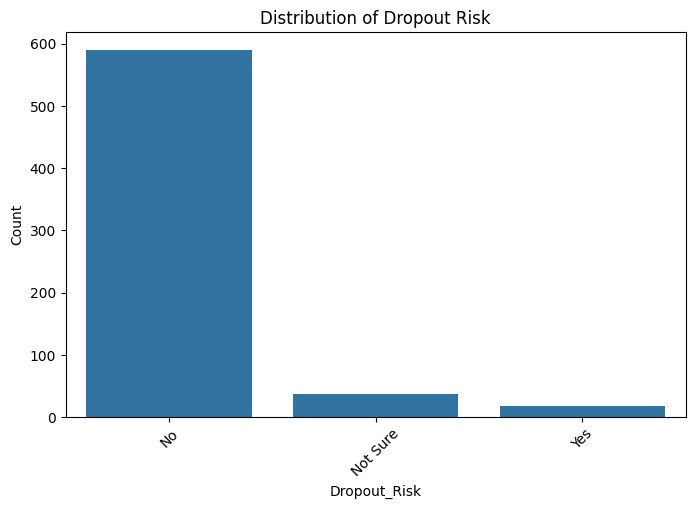

Dropout_Risk
No          91.601866
Not Sure     5.754277
Yes          2.643857
Name: proportion, dtype: float64


In [29]:
# Distribution of Target (CGPA_Range)

plt.figure(figsize=(8,5))
sns.countplot(x='Dropout_Risk', data=data, order=data['Dropout_Risk'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Distribution of Dropout Risk")
plt.xlabel("Dropout_Risk")
plt.ylabel("Count")
plt.show()

dropout_dist = data['Dropout_Risk'].value_counts(normalize=True) * 100
print(dropout_dist)


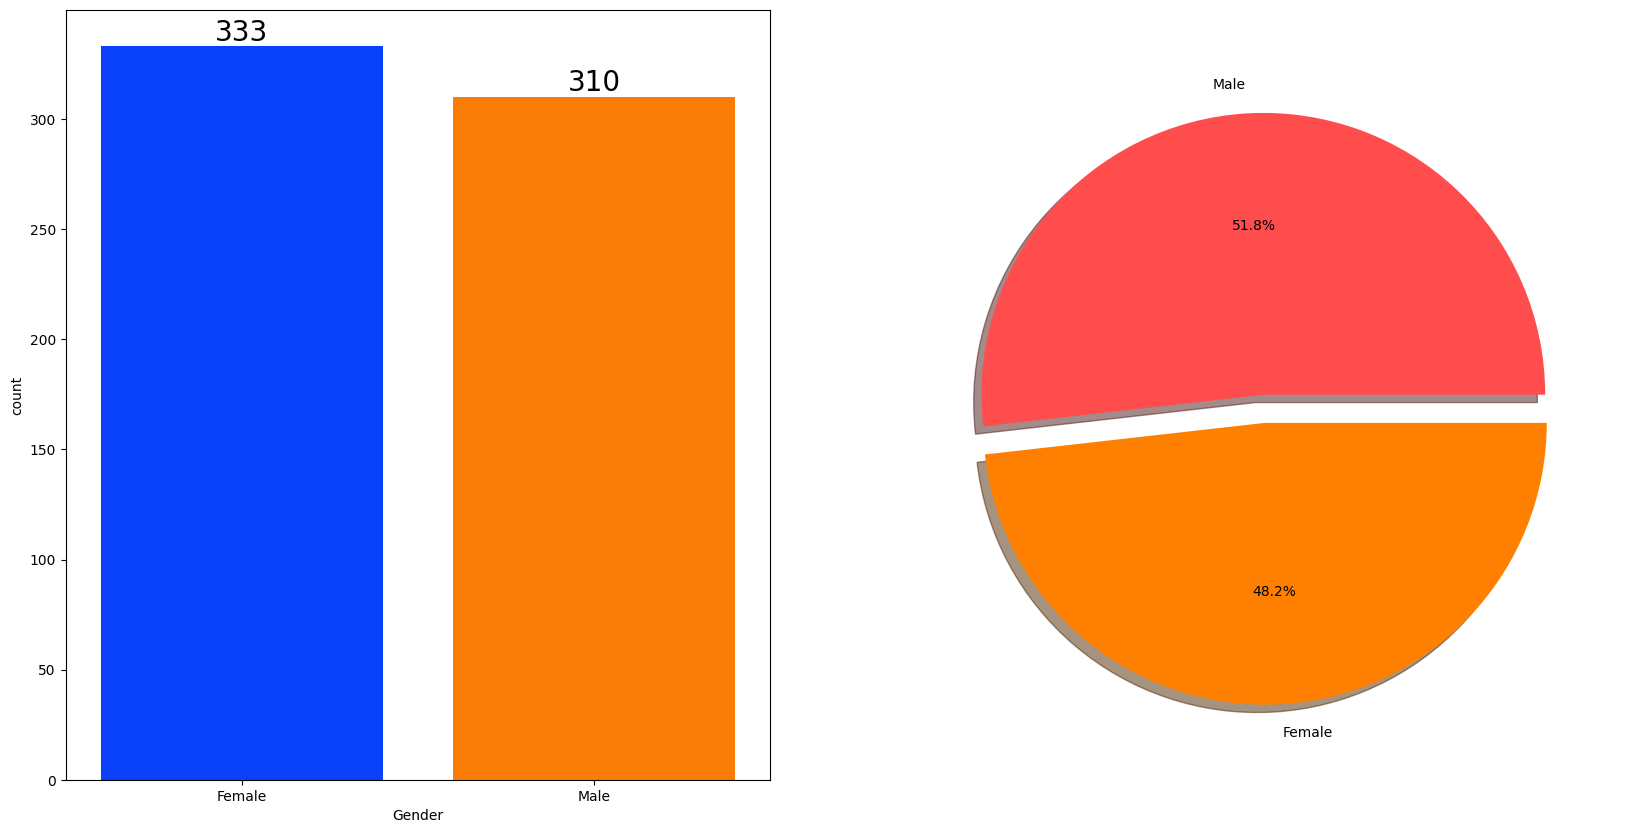

In [30]:
# Distribution of Gender
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=data['Gender'],data=data,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=data['Gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

gender = data['Gender'].value_counts(normalize=True) * 100

### Insight
The dataset consists of 48.21% male and 51.78% female students, indicating a almost balance gender distribution

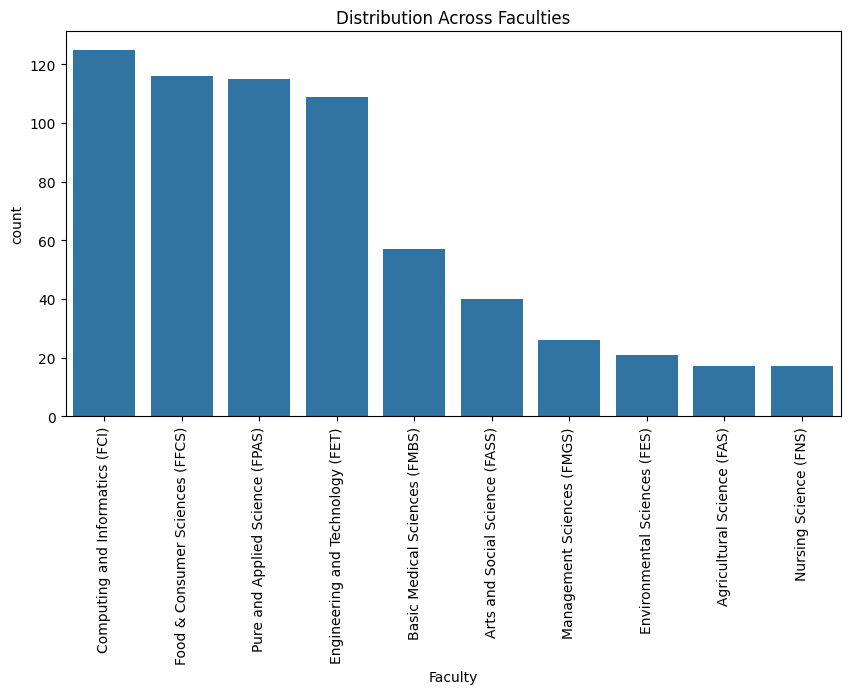

Faculty
Computing and Informatics (FCI)     19.440124
Food & Consumer Sciences (FFCS)     18.040435
Pure and Applied Science (FPAS)     17.884914
Engineering and Technology (FET)    16.951788
Basic Medical Sciences (FMBS)        8.864697
Arts and Social Science (FASS)       6.220840
Management Sciences (FMGS)           4.043546
Environmental Sciences (FES)         3.265941
Agricultural Science (FAS)           2.643857
Nursing Science (FNS)                2.643857
Name: proportion, dtype: float64


In [31]:
# Distribution on Facultyb
plt.figure(figsize=(10,5))
sns.countplot(x='Faculty', data=data, order=data['Faculty'].value_counts().index)
plt.xticks(rotation=90)
plt.title("Distribution Across Faculties")
plt.show()

print(data['Faculty'].value_counts(normalize=True) * 100)

### Insight
The majority of respondents are from FCI, which may influence the overall academic performance distribution

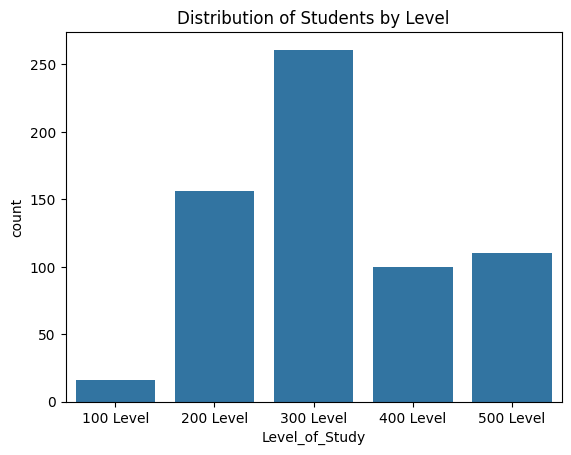

Level_of_Study
300 Level    40.590980
200 Level    24.261275
500 Level    17.107309
400 Level    15.552100
100 Level     2.488336
Name: proportion, dtype: float64


In [32]:
# Distribution on Level of study
sns.countplot(x='Level_of_Study', data=data, order=['100 Level','200 Level','300 Level','400 Level','500 Level'])
plt.title("Distribution of Students by Level")
plt.show()

print(data['Level_of_Study'].value_counts(normalize=True) * 100)

### Insight 
A large proportion of students study between 5-10 hours weekly, indicating moderate study habits among respondents.

## Bivariate 
Distribution on two features (One categorical vs Target)

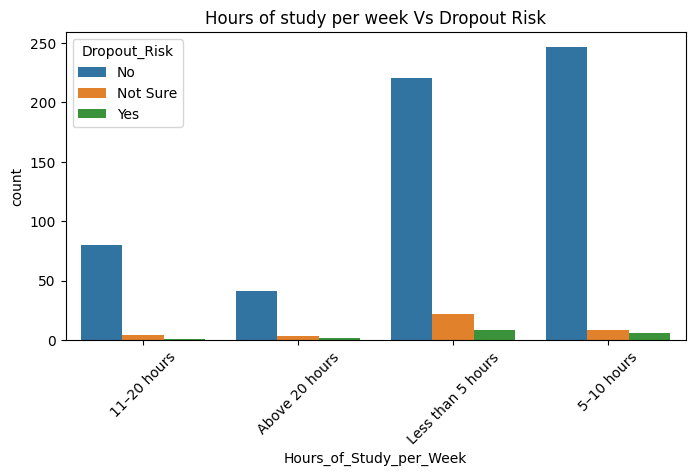

Percentage of Dropout Risk vs Hours of study per week:

Dropout_Risk                    No  Not Sure       Yes
Hours_of_Study_per_Week                               
11–20 hours              94.117647  4.705882  1.176471
5–10 hours               94.636015  3.065134  2.298851
Above 20 hours           89.130435  6.521739  4.347826
Less than 5 hours        88.047809  8.764940  3.187251


In [33]:
## Distribution on Study hour vs Dropout risk (Categorical vs Target)
plt.figure(figsize=(8,4))
sns.countplot(x='Hours_of_Study_per_Week', hue='Dropout_Risk', data=data)
plt.xticks(rotation=45)
plt.title('Hours of study per week Vs Dropout Risk')
plt.show()

drpout_crosstab = pd.crosstab(data['Hours_of_Study_per_Week'], data['Dropout_Risk'], normalize='index')*100
print("Percentage of Dropout Risk vs Hours of study per week:\n")
print(drpout_crosstab)

### Insight:
The relationship between study hours and dropout risk is non-linear, where both under-studying and over-studying are associated with higher dropout risk, while a moderate study range (11–20 hours) appears to be the most effective for reducing dropout likelihood.

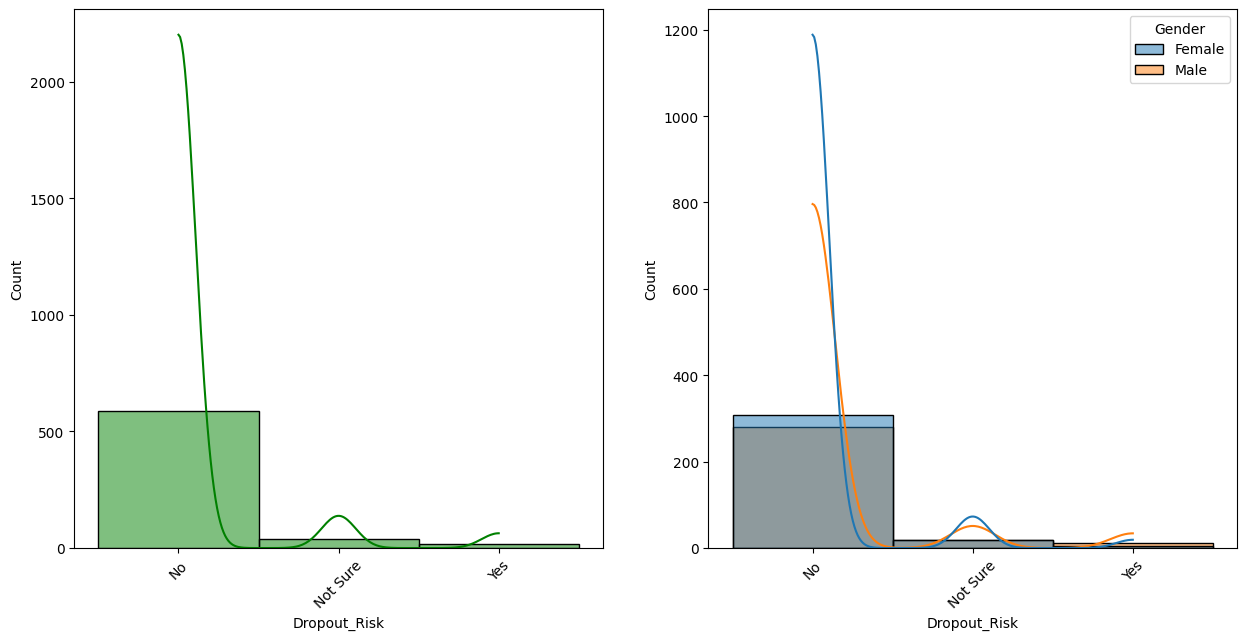

Percentage ofDropout Risk vs Gender:

Dropout_Risk         No  Not Sure       Yes
Gender                                     
Female        92.792793  5.705706  1.501502
Male          90.322581  5.806452  3.870968


In [34]:
# Distribution on Gender vs Dropout
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=data,x='Dropout_Risk',bins=30,kde=True,color='g')
plt.xticks(rotation=(45))
plt.subplot(122)
sns.histplot(data=data,x='Dropout_Risk',kde=True,hue='Gender')
plt.xticks(rotation=(45))

plt.show()

drpout_crosstab = pd.crosstab(data['Gender'], data['Dropout_Risk'], normalize='index')*100
print("Percentage ofDropout Risk vs Gender:\n")
print(drpout_crosstab)

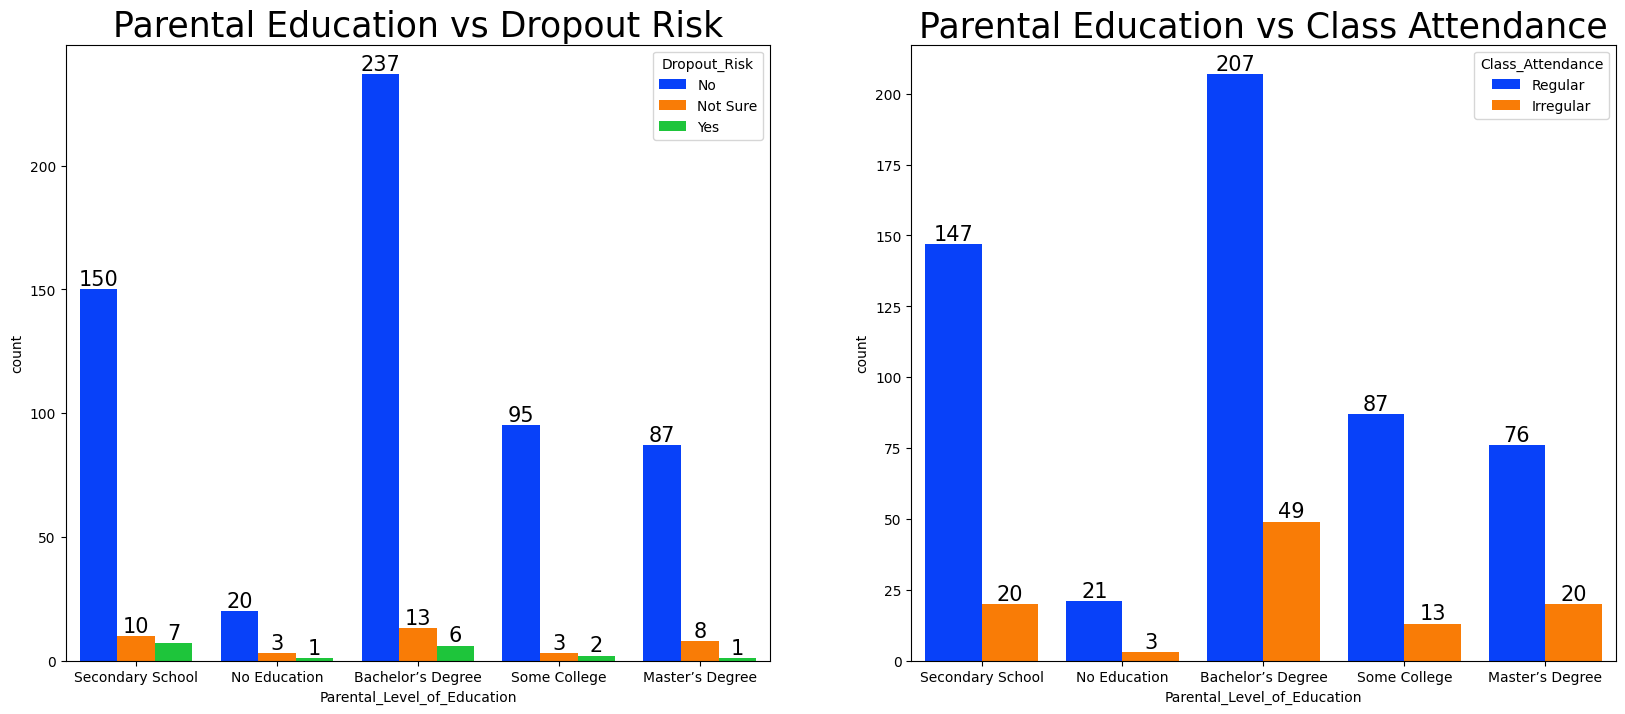

In [35]:
f, ax = plt.subplots(1, 2, figsize=(20, 8))

# Subplot 1: Parental Education vs Dropout Risk
sns.countplot(
    x=data['Parental_Level_of_Education'],
    data=data,
    palette='bright',
    hue='Dropout_Risk',
    saturation=0.95,
    ax=ax[0]
)
ax[0].set_title('Parental Education vs Dropout Risk', color='black', size=25)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=15)

# Subplot 2: Optional: Parental Education vs Another Feature (e.g., Class Attendance)
sns.countplot(
    x=data['Parental_Level_of_Education'],
    data=data,
    palette='bright',
    hue='Class_Attendance',
    saturation=0.95,
    ax=ax[1]
)
ax[1].set_title('Parental Education vs Class Attendance', color='black', size=25)
for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=15)

plt.show()

### Insight:
-Students whose parents have higher education (Bachelor’s/Master’s) show lower dropout intention.

-Dropout intention is higher for students whose parents have secondary education or none.

-This indicates parental education is an important factor influencing dropout intention.

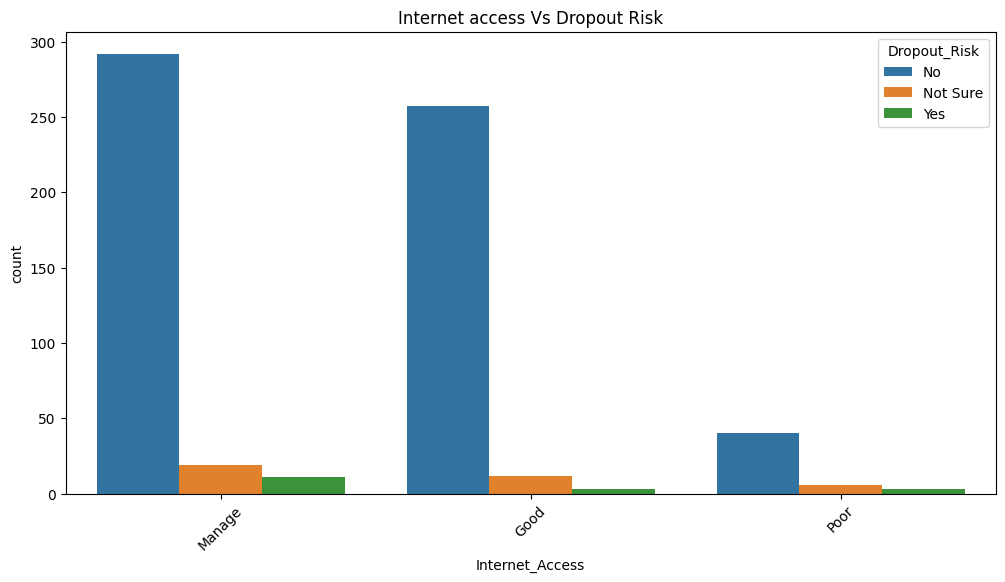

Percentage of Dropout Risk vs Internet access:

Dropout_Risk            No   Not Sure       Yes
Internet_Access                                
Good             94.485294   4.411765  1.102941
Manage           90.683230   5.900621  3.416149
Poor             81.632653  12.244898  6.122449


In [36]:
## Distribution on Internet vs Dropout risk (Categorical vs Target)
plt.figure(figsize=(12,6))
sns.countplot(x='Internet_Access', hue='Dropout_Risk', data=data)
plt.xticks(rotation=45)
plt.title('Internet access Vs Dropout Risk')
plt.show()

dropout_crosstab = pd.crosstab(data['Internet_Access'], data['Dropout_Risk'], normalize='index')*100
print("Percentage of Dropout Risk vs Internet access:\n")
print(dropout_crosstab)

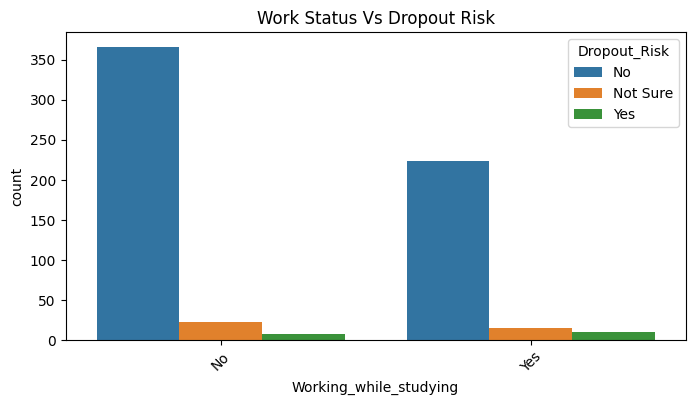

Percentage of Dropout Risk vs Work status:

Dropout_Risk                   No  Not Sure       Yes
Working_while_studying                               
No                      92.658228  5.569620  1.772152
Yes                     89.919355  6.048387  4.032258


In [37]:
## Distribution on Work status vs Dropout risk (Categorical vs Target)
plt.figure(figsize=(8,4))
sns.countplot(x='Working_while_studying', hue='Dropout_Risk', data=data)
plt.xticks(rotation=45)
plt.title('Work Status Vs Dropout Risk')
plt.show()

dropout_crosstab = pd.crosstab(data['Working_while_studying'], data['Dropout_Risk'], normalize='index')*100
print("Percentage of Dropout Risk vs Work status:\n")
print(dropout_crosstab)

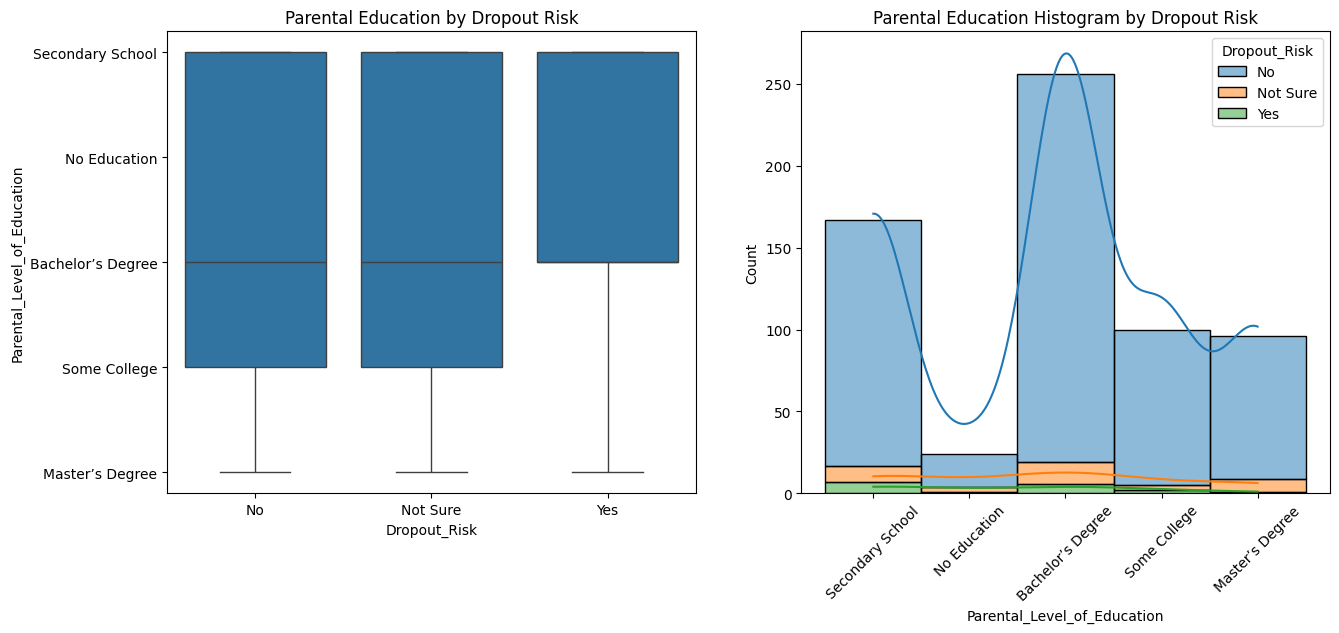

Parental Education Statistics by Dropout Risk:

             count unique                top freq
Dropout_Risk                                     
No             589      5  Bachelor’s Degree  237
Not Sure        37      5  Bachelor’s Degree   13
Yes             17      5   Secondary School    7


In [38]:
## Distribution on Parent level education vs Dropout Risk  (Categorical vs Target)
fig, axs = plt.subplots(1, 2, figsize=(15,6))

# First subplot
plt.subplot(121)
sns.boxplot(x='Dropout_Risk', y='Parental_Level_of_Education', data=data)
plt.title('Parental Education by Dropout Risk')

# Second subplot
plt.subplot(122)
plt.xticks(rotation=(45))
sns.histplot(data=data, x='Parental_Level_of_Education', kde=True, hue='Dropout_Risk', multiple='stack')
plt.title('Parental Education Histogram by Dropout Risk')

plt.show()

print("Parental Education Statistics by Dropout Risk:\n")
print(data.groupby('Dropout_Risk')['Parental_Level_of_Education'].describe())

### Insight:
 Higher parental education appears associated with lower dropout intention.

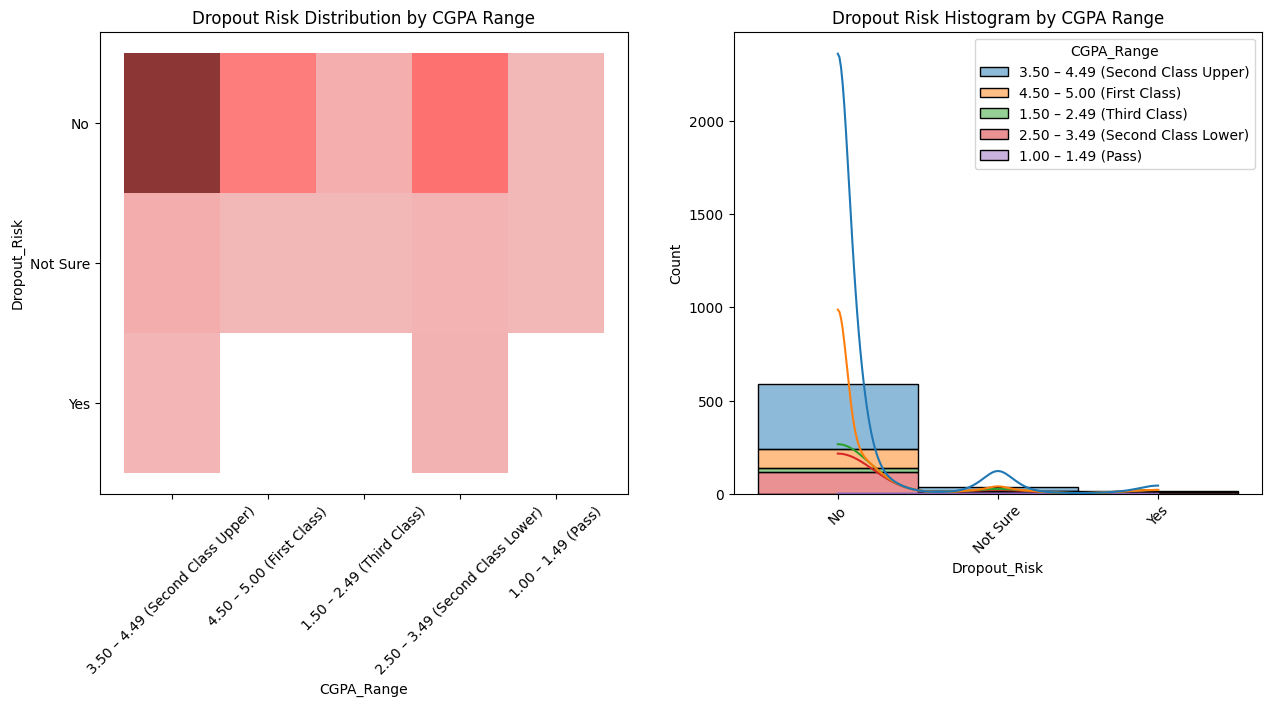

Percentage of Dropout Risk vs CGPA Range:

Dropout_Risk                             No   Not Sure       Yes
CGPA_Range                                                      
1.00 – 1.49 (Pass)                33.333333  66.666667  0.000000
1.50 – 2.49 (Third Class)         90.909091   9.090909  0.000000
2.50 – 3.49 (Second Class Lower)  84.782609   7.246377  7.971014
3.50 – 4.49 (Second Class Upper)  92.857143   5.555556  1.587302
4.50 – 5.00 (First Class)         98.039216   1.960784  0.000000


In [39]:
fig, axs = plt.subplots(1, 2, figsize=(15,6))

plt.subplot(121)
sns.histplot(x='CGPA_Range', y='Dropout_Risk', data=data, kde=True, color='r', bins=30)
plt.xticks(rotation=45)
plt.title('Dropout Risk Distribution by CGPA Range')

plt.subplot(122)
sns.histplot(data=data, x='Dropout_Risk', kde=True, hue='CGPA_Range', multiple='stack')
plt.xticks(rotation=45)
plt.title('Dropout Risk Histogram by CGPA Range')

plt.show()


dropout_crosstab = pd.crosstab(data['CGPA_Range'], data['Dropout_Risk'], normalize='index')*100
print("Percentage of Dropout Risk vs CGPA Range:\n")
print(dropout_crosstab)

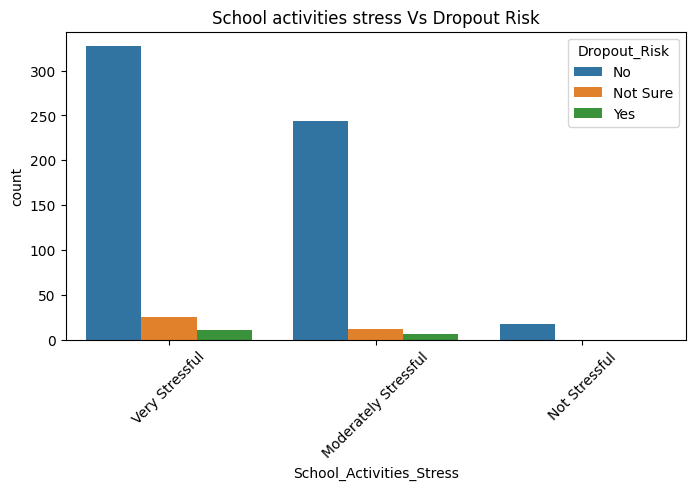

Percentage of Dropout Risk vs School activities stress:

Dropout_Risk                      No  Not Sure       Yes
School_Activities_Stress                                
Moderately Stressful       93.129771  4.580153  2.290076
Not Stressful             100.000000  0.000000  0.000000
Very Stressful             90.082645  6.887052  3.030303


In [40]:
## Distribution on School activities stress vs Dropout Risk (Categorical vs Target)
plt.figure(figsize=(8,4))
sns.countplot(x='School_Activities_Stress', hue='Dropout_Risk', data=data)
plt.xticks(rotation=45)
plt.title('School activities stress Vs Dropout Risk')
plt.show()

dropout_crosstab = pd.crosstab(data['School_Activities_Stress'], data['Dropout_Risk'], normalize='index')*100
print("Percentage of Dropout Risk vs School activities stress:\n")
print(dropout_crosstab)

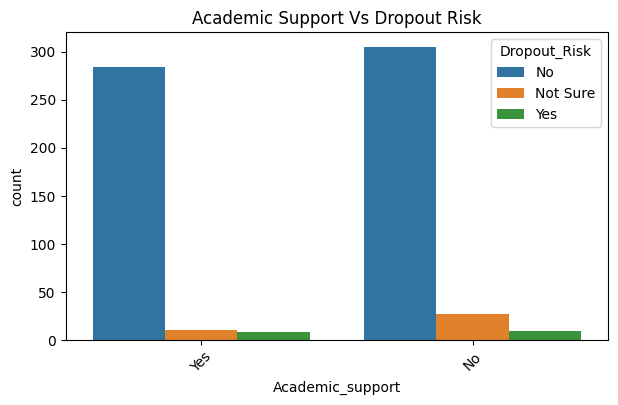

Percentage of Dropout Risk vs Academic Support:

Dropout_Risk             No  Not Sure       Yes
Academic_support                               
No                89.442815  7.917889  2.639296
Yes               94.039735  3.311258  2.649007


In [41]:
## Distribution on Academic support vs Dropout Risk (Categorical vs Target)
plt.figure(figsize=(7,4))
sns.countplot(x='Academic_support', hue='Dropout_Risk', data=data)
plt.xticks(rotation=45)
plt.title('Academic Support Vs Dropout Risk')
plt.show()

dropout_crosstab = pd.crosstab(data['Academic_support'], data['Dropout_Risk'], normalize='index')*100
print("Percentage of Dropout Risk vs Academic Support:\n")
print(dropout_crosstab)

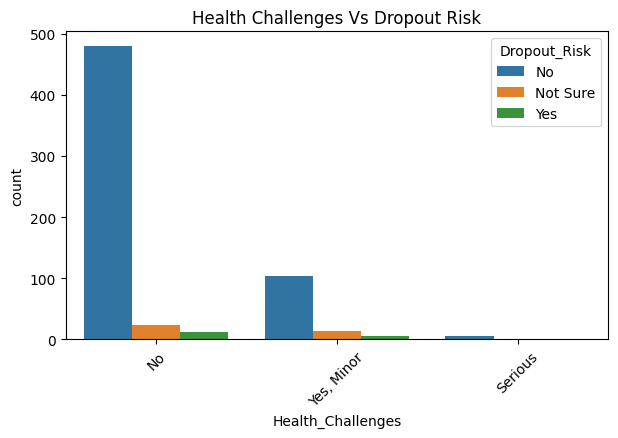

Percentage of Dropout Risk vs Health Challenges:

Dropout_Risk               No   Not Sure       Yes
Health_Challenges                                 
No                  93.023256   4.651163  2.325581
Serious            100.000000   0.000000  0.000000
Yes, Minor          85.123967  10.743802  4.132231


In [42]:
## Distribution on Health Challenges vs Dropout Risk (Categorical vs Target)
plt.figure(figsize=(7,4))
sns.countplot(x='Health_Challenges', hue='Dropout_Risk', data=data)
plt.xticks(rotation=45)
plt.title('Health Challenges Vs Dropout Risk')
plt.show()

dropout_crosstab = pd.crosstab(data['Health_Challenges'], data['Dropout_Risk'], normalize='index')*100
print("Percentage of Dropout Risk vs Health Challenges:\n")
print(dropout_crosstab)

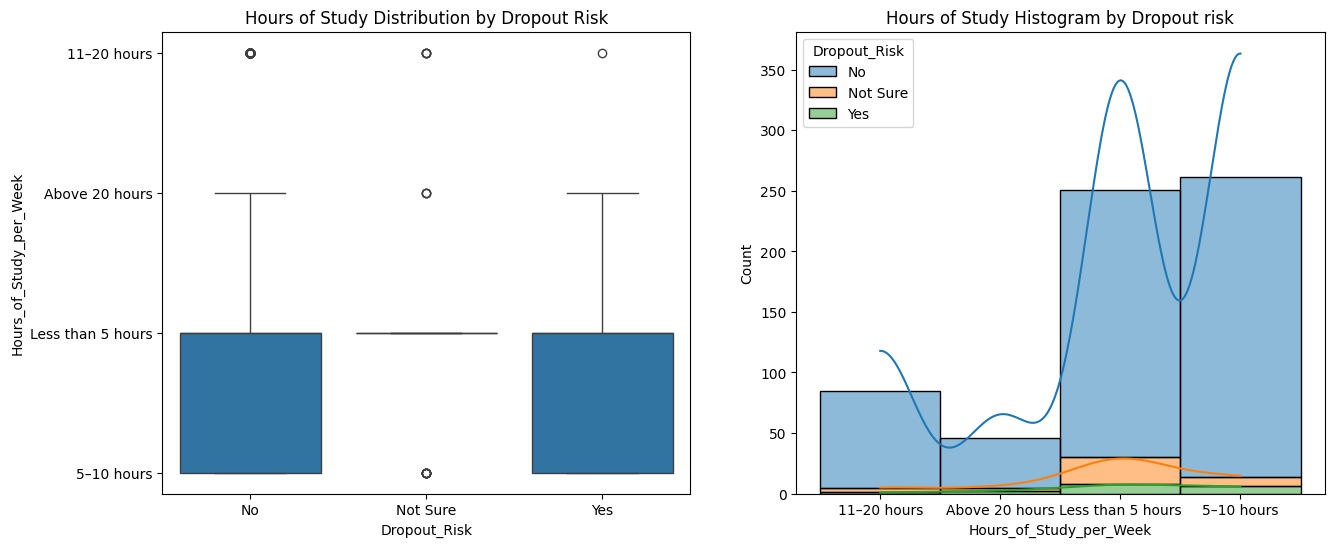

Hours of Study Statistics by Dropout risk:

             count unique                top freq
Dropout_Risk                                     
No             589      4         5–10 hours  247
Not Sure        37      4  Less than 5 hours   22
Yes             17      4  Less than 5 hours    8


In [43]:
fig, axs = plt.subplots(1, 2, figsize=(15,6))

plt.subplot(121)
sns.boxplot(x='Dropout_Risk', y='Hours_of_Study_per_Week', data=data)
plt.title('Hours of Study Distribution by Dropout Risk')

plt.subplot(122)
sns.histplot(data=data, x='Hours_of_Study_per_Week', kde=True, hue='Dropout_Risk', multiple='stack')
plt.title('Hours of Study Histogram by Dropout risk')

plt.show()

print("Hours of Study Statistics by Dropout risk:\n")
print(data.groupby('Dropout_Risk')['Hours_of_Study_per_Week'].describe())

### Insight:
Students who study more hours per week are less likely to intend to dropout.

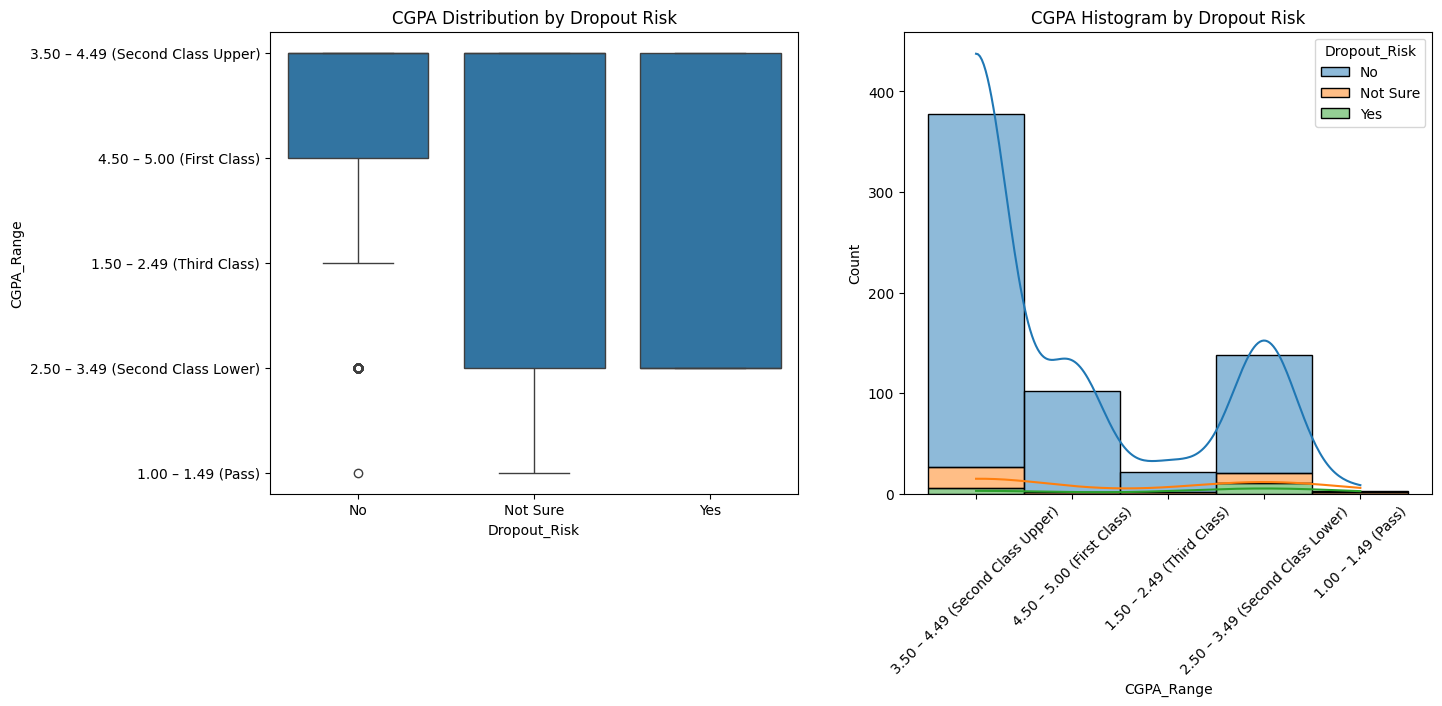

CGPA Statistics by Dropout Risk:

             count unique                               top freq
Dropout_Risk                                                    
No             589      5  3.50 – 4.49 (Second Class Upper)  351
Not Sure        37      5  3.50 – 4.49 (Second Class Upper)   21
Yes             17      2  2.50 – 3.49 (Second Class Lower)   11


In [44]:
fig, axs = plt.subplots(1, 2, figsize=(15,6))

plt.subplot(121)
sns.boxplot(x='Dropout_Risk', y='CGPA_Range', data=data)
plt.title('CGPA Distribution by Dropout Risk')

plt.subplot(122)
sns.histplot(data=data, x='CGPA_Range', kde=True, hue='Dropout_Risk', multiple='stack')
plt.xticks(rotation=45)
plt.title('CGPA Histogram by Dropout Risk')

plt.show()

print("CGPA Statistics by Dropout Risk:\n")
print(data.groupby('Dropout_Risk')['CGPA_Range'].describe())


### Insight:
- Students with higher CGPA are less likely to intend to dropout.
- Dropout group concentrated in lower CGPA ranges.

## Multivariate 
Look at how multiple variables interact to affect the target (Dropout)

## Feature Engineering

In [45]:
### Mapping Binary features and Ordinal features

data['Gender'] = data['Gender'].map({
    'Male':0,
    'Female':1
})

data['Accommodation_Type'] = data['Accommodation_Type'].map({
    'Squatting':0,
    'Hostel':1
})

data['Working_while_studying'] = data['Working_while_studying'].map({
    'No':0,
    'Yes':1
})

data['Participation_in_Social_Activities'] = data['Participation_in_Social_Activities'].map({
    'No':0,
    'Yes':1
})

data['Scholarship_Status'] = data['Scholarship_Status'].map({
    'No':0,
    'Yes':1
})

data['Academic_support'] = data['Academic_support'].map({
    'No':0,
    'Yes':1
})


## Ordinal Features

# Age_Range
data['Age_Range'] = data['Age_Range'].map({
'16–19 years':0,
'20–23 years':1,
'24–27 years':2,
'28–30 years':3
})

# Level of Study
data['Level_of_Study'] = data['Level_of_Study'].map({
'100 Level':0,
'200 Level':1,
'300 Level':2,
'400 Level':3,
'500 Level':4
})

# Health Challenge
data['Health_Challenges'] = data['Health_Challenges'].map({
'No':0,
'Yes, Minor':1,
'Serious':2
})

# School Activities Stress
data['School_Activities_Stress'] = data['School_Activities_Stress'].map({
    'Not Stressful':0,
    'Moderately Stressful':1,
    'Very Stressful':2
})

# Internet Access
data['Internet_Access'] = data['Internet_Access'].map({
'Poor':0,
'Manage':1,
'Good':2
})

# CGPA Range
data['CGPA_Range'] = data['CGPA_Range'].map({
    'Below 1.00 (Probation)': 0,
    '1.00 – 1.49 (Pass)': 1,
    '1.50 – 2.49 (Third Class)': 2,
    '2.50 – 3.49 (Second Class Lower)': 3,
    '3.50 – 4.49 (Second Class Upper)': 4,
    '4.50 – 5.00 (First Class)': 5
})

# Parental Level of Education
data['Parental_Level_of_Education'] = data['Parental_Level_of_Education'].map({
    'No Education': 0,
    'Secondary School': 1,
    'Some College': 2,
    'Bachelor’s Degree': 3,
    'Master’s Degree': 4
})

# Hours of Study per Week
data['Hours_of_Study_per_Week'] = data['Hours_of_Study_per_Week'].map({
    'Less than 5 hours': 0,
    '5–10 hours': 1,
    '11–20 hours': 2,
    'Above 20 hours': 3
})

# Class Attendance
data['Class_Attendance'] = data['Class_Attendance'].map({
    'Irregular': 0,
    'Regular': 1
})

# Dropout Intention (Mapping first and then creating binary target)
data['Dropout_Risk'] = data['Dropout_Risk'].map({
    'No': 0,
    'Not Sure': 1,
    'Yes': 2
})
data['Dropout_Risk'] = data['Dropout_Risk'].replace({
    0: 0,
    1: 1,
    2: 1
})

In [46]:
data.head()

,Gender,Age_Range,Admission_Year,Faculty,Level_of_Study,Parental_Level_of_Education,Financial_Support_Source,CGPA_Range,Hours_of_Study_per_Week,Class_Attendance,Accommodation_Type,Working_while_studying,Internet_Access,Participation_in_Social_Activities,Scholarship_Status,Academic_support,Health_Challenges,School_Activities_Stress,Dropout_Risk
0,1,1,2023/2024,Food & Consumer Sciences (FFCS),2,1,Parents/Guardians,4,2,1,1,0,1,0,0,1,0,2,0
1,0,1,2021/2022,Computing and Informatics (FCI),4,0,Parents/Guardians,4,3,0,1,0,1,0,0,0,1,1,0
2,0,1,2021/2022,Computing and Informatics (FCI),4,3,Parents/Guardians,4,0,1,1,0,2,0,0,1,1,2,0
3,0,1,2021/2022,Computing and Informatics (FCI),4,3,Parents/Guardians,5,1,1,1,0,1,0,0,0,0,0,0
4,0,1,2021/2022,Computing and Informatics (FCI),4,2,Parents/Guardians,5,0,0,1,0,1,0,0,0,0,1,0


In [47]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 643 entries, 0 to 642
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Gender                              643 non-null    int64
 1   Age_Range                           643 non-null    int64
 2   Admission_Year                      643 non-null    str  
 3   Faculty                             643 non-null    str  
 4   Level_of_Study                      643 non-null    int64
 5   Parental_Level_of_Education         643 non-null    int64
 6   Financial_Support_Source            643 non-null    str  
 7   CGPA_Range                          643 non-null    int64
 8   Hours_of_Study_per_Week             643 non-null    int64
 9   Class_Attendance                    643 non-null    int64
 10  Accommodation_Type                  643 non-null    int64
 11  Working_while_studying              643 non-null    int64
 12  Internet_Access    

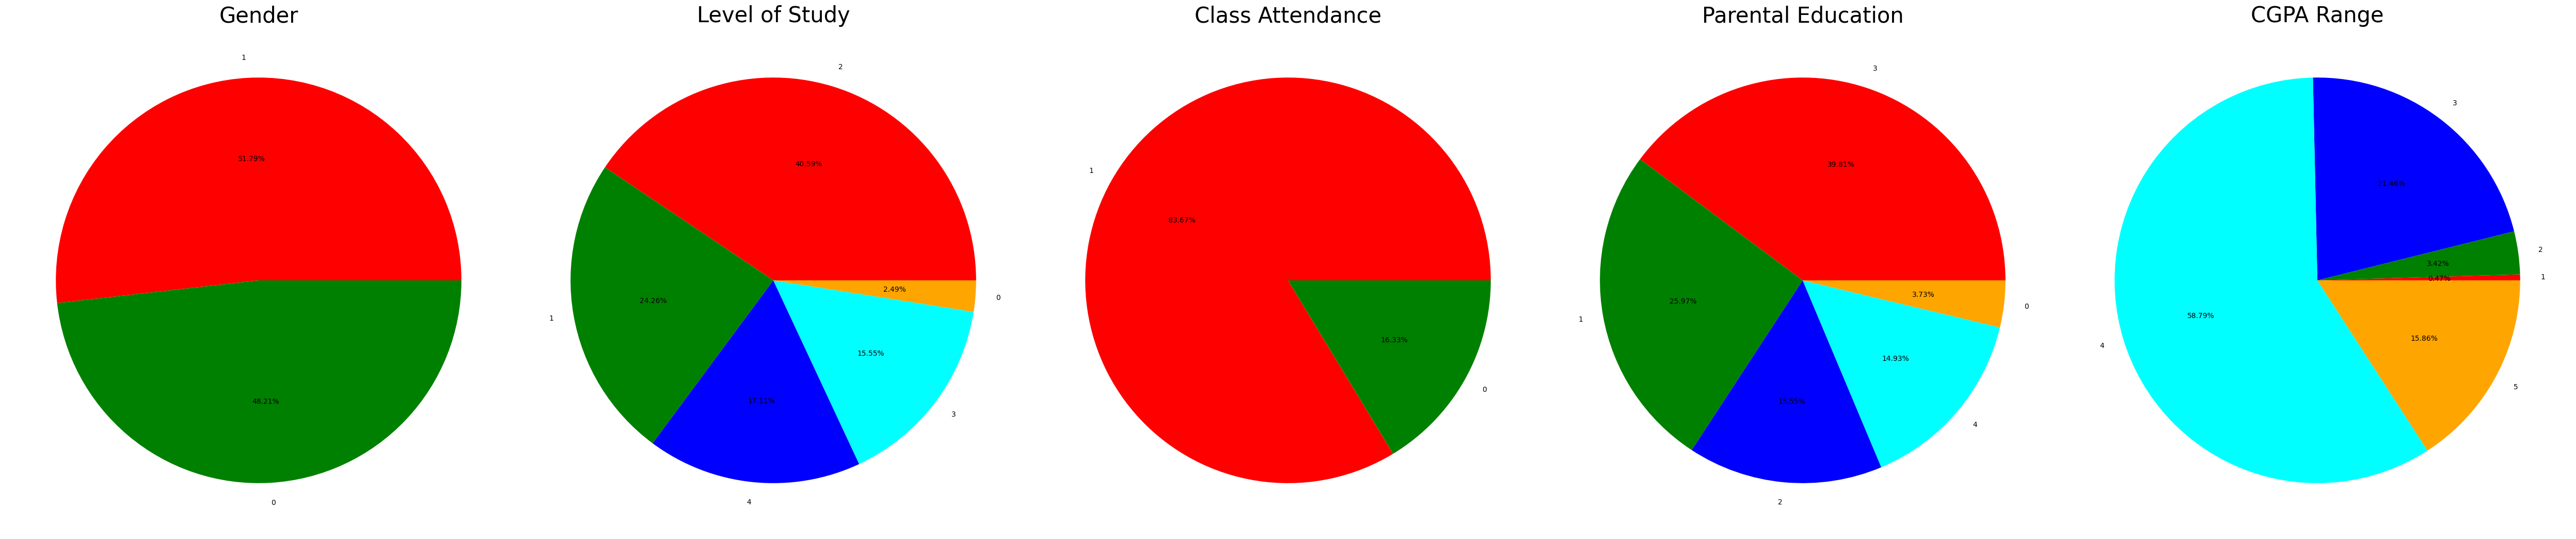

In [48]:
# Set figure size
plt.rcParams['figure.figsize'] = (50, 20)

# --- Gender ---
plt.subplot(1, 5, 1)
size = data['Gender'].value_counts()
labels = size.index  # automatically gets 'Female', 'Male'
colors = ['red', 'green']
plt.pie(size, colors=colors, labels=labels, autopct='%.2f%%')
plt.title('Gender', fontsize=30)
plt.axis('off')

# --- Level of Study ---
plt.subplot(1, 5, 2)
size = data['Level_of_Study'].value_counts()
labels = size.index
colors = ['red', 'green', 'blue', 'cyan', 'orange', 'grey'][:len(labels)]
plt.pie(size, colors=colors, labels=labels, autopct='%.2f%%')
plt.title('Level of Study', fontsize=30)
plt.axis('off')

# --- Class Attendance ---
plt.subplot(1, 5, 3)
size = data['Class_Attendance'].value_counts()
labels = size.index
colors = ['red', 'green']
plt.pie(size, colors=colors, labels=labels, autopct='%.2f%%')
plt.title('Class Attendance', fontsize=30)
plt.axis('off')

# --- Parental Education ---
plt.subplot(1, 5, 4)
size = data['Parental_Level_of_Education'].value_counts()
labels = size.index
colors = ['red', 'green', 'blue', 'cyan', 'orange', 'grey'][:len(labels)]
plt.pie(size, colors=colors, labels=labels, autopct='%.2f%%')
plt.title('Parental Education', fontsize=30)
plt.axis('off')

# --- CGPA Range ---
plt.subplot(1, 5, 5)
size = data['CGPA_Range'].value_counts().sort_index()  # keeps ordinal order
labels = size.index
colors = ['red', 'green', 'blue', 'cyan', 'orange', 'grey'][:len(labels)]
plt.pie(size, colors=colors, labels=labels, autopct='%.2f%%')
plt.title('CGPA Range', fontsize=30)
plt.axis('off')

plt.tight_layout()
plt.show()

#####  Insights
- Number of Male and Female students are almost equal
- Number students are greatest in 300 Level
- Number of students who attend class regular are greater
- Number of students whose parental level of education education is "Secondary School" is greater followed closely by "Master's degree"
- Number of students who in second class upper are greater

## Correlation heatmap

<Axes: >

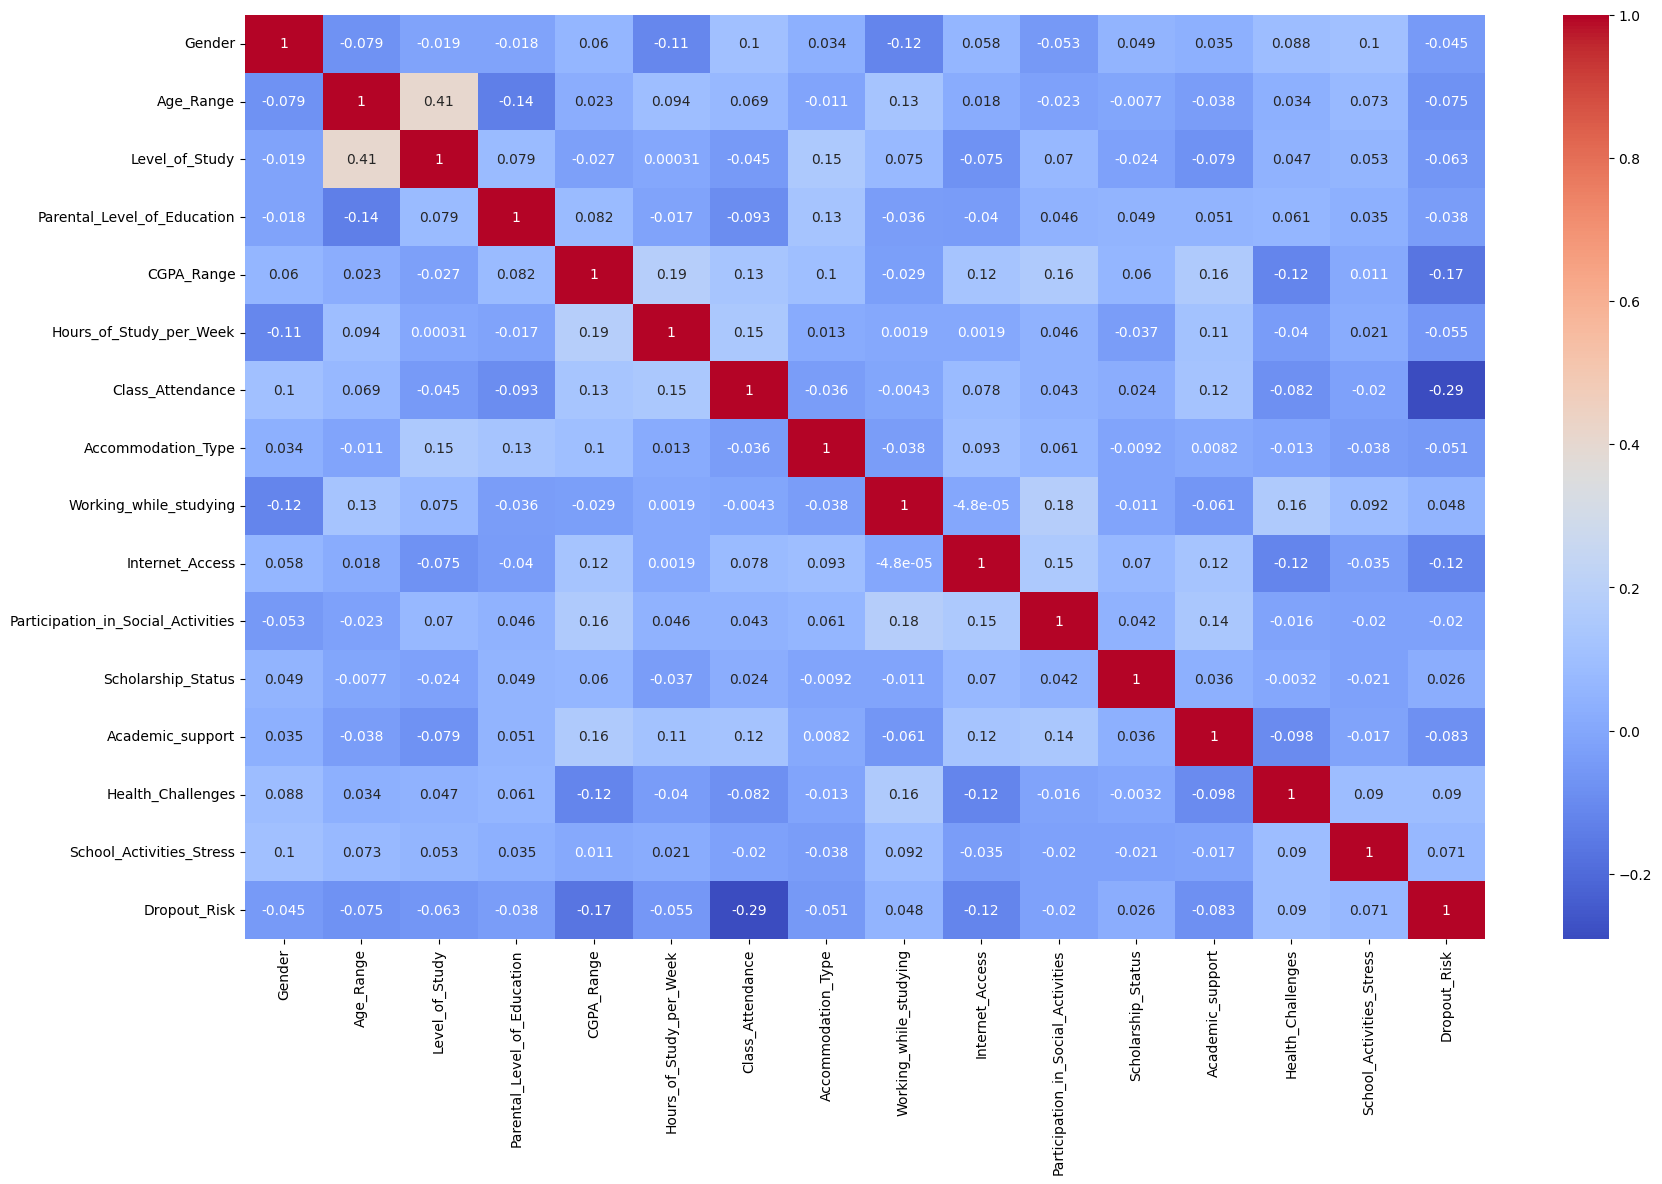

In [49]:
# Compute correlation matrix
plt.figure(figsize=(20, 12))

numeric_data = data.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm")

### Insight:
Numeric features show strong positive correlations, indicating that higher study hours, class attendance, and CGPA tend to increase together

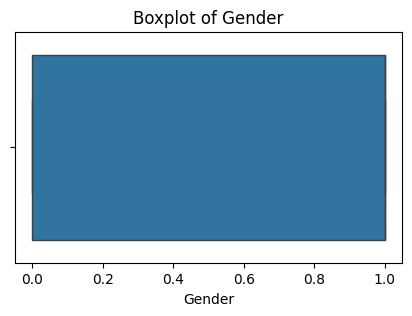

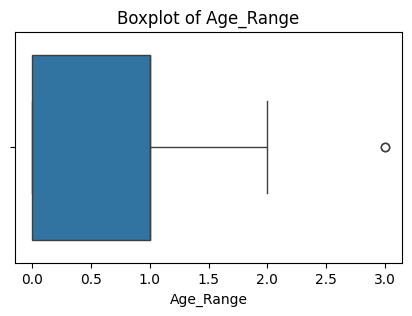

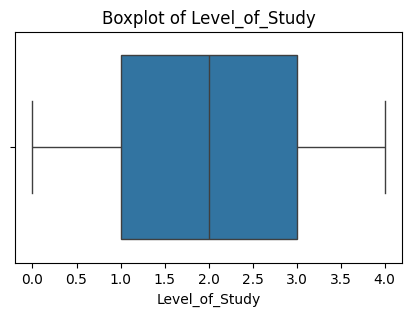

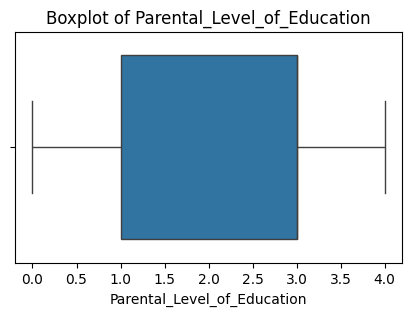

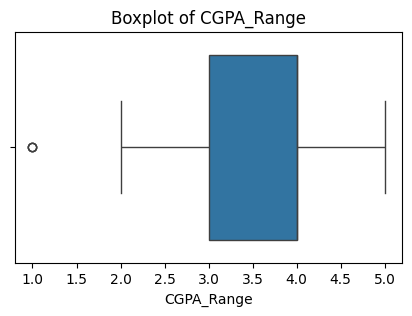

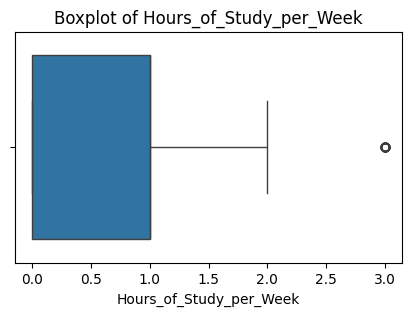

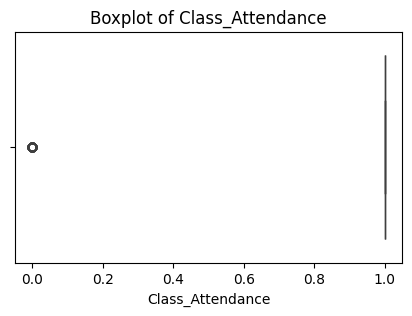

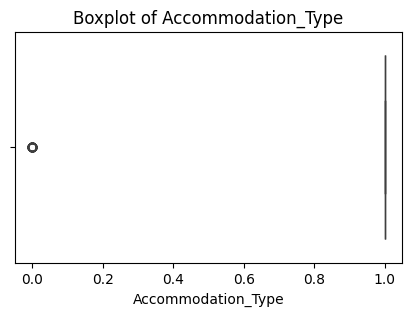

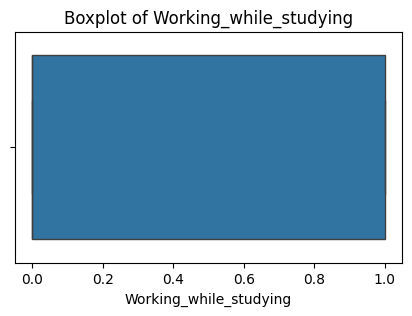

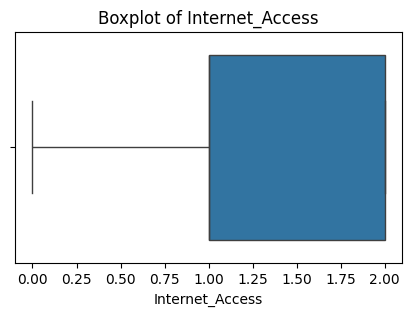

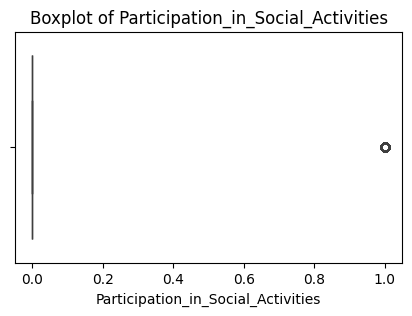

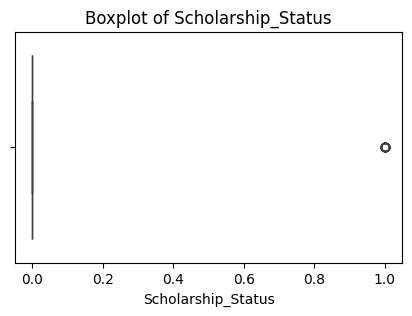

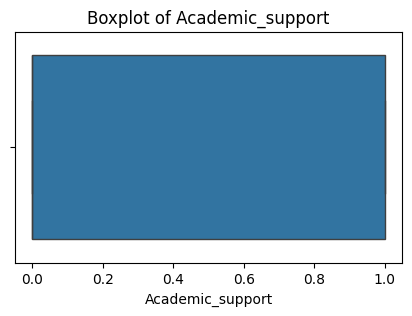

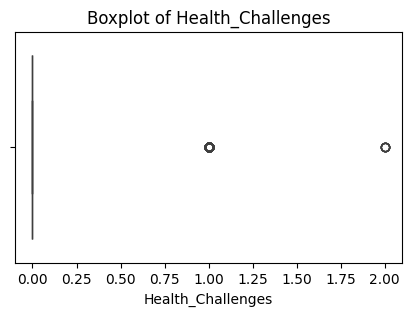

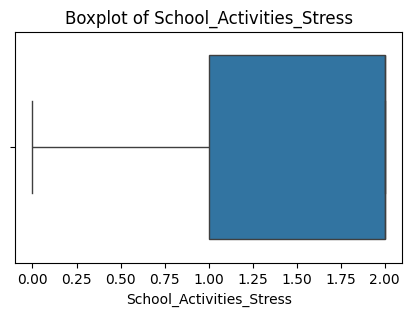

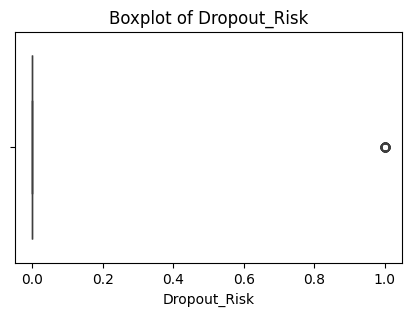

In [50]:
## Checking for outlier
numeric_cols = data.select_dtypes(include=['int64', 'int32']).columns

for col in numeric_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

## Pairplot

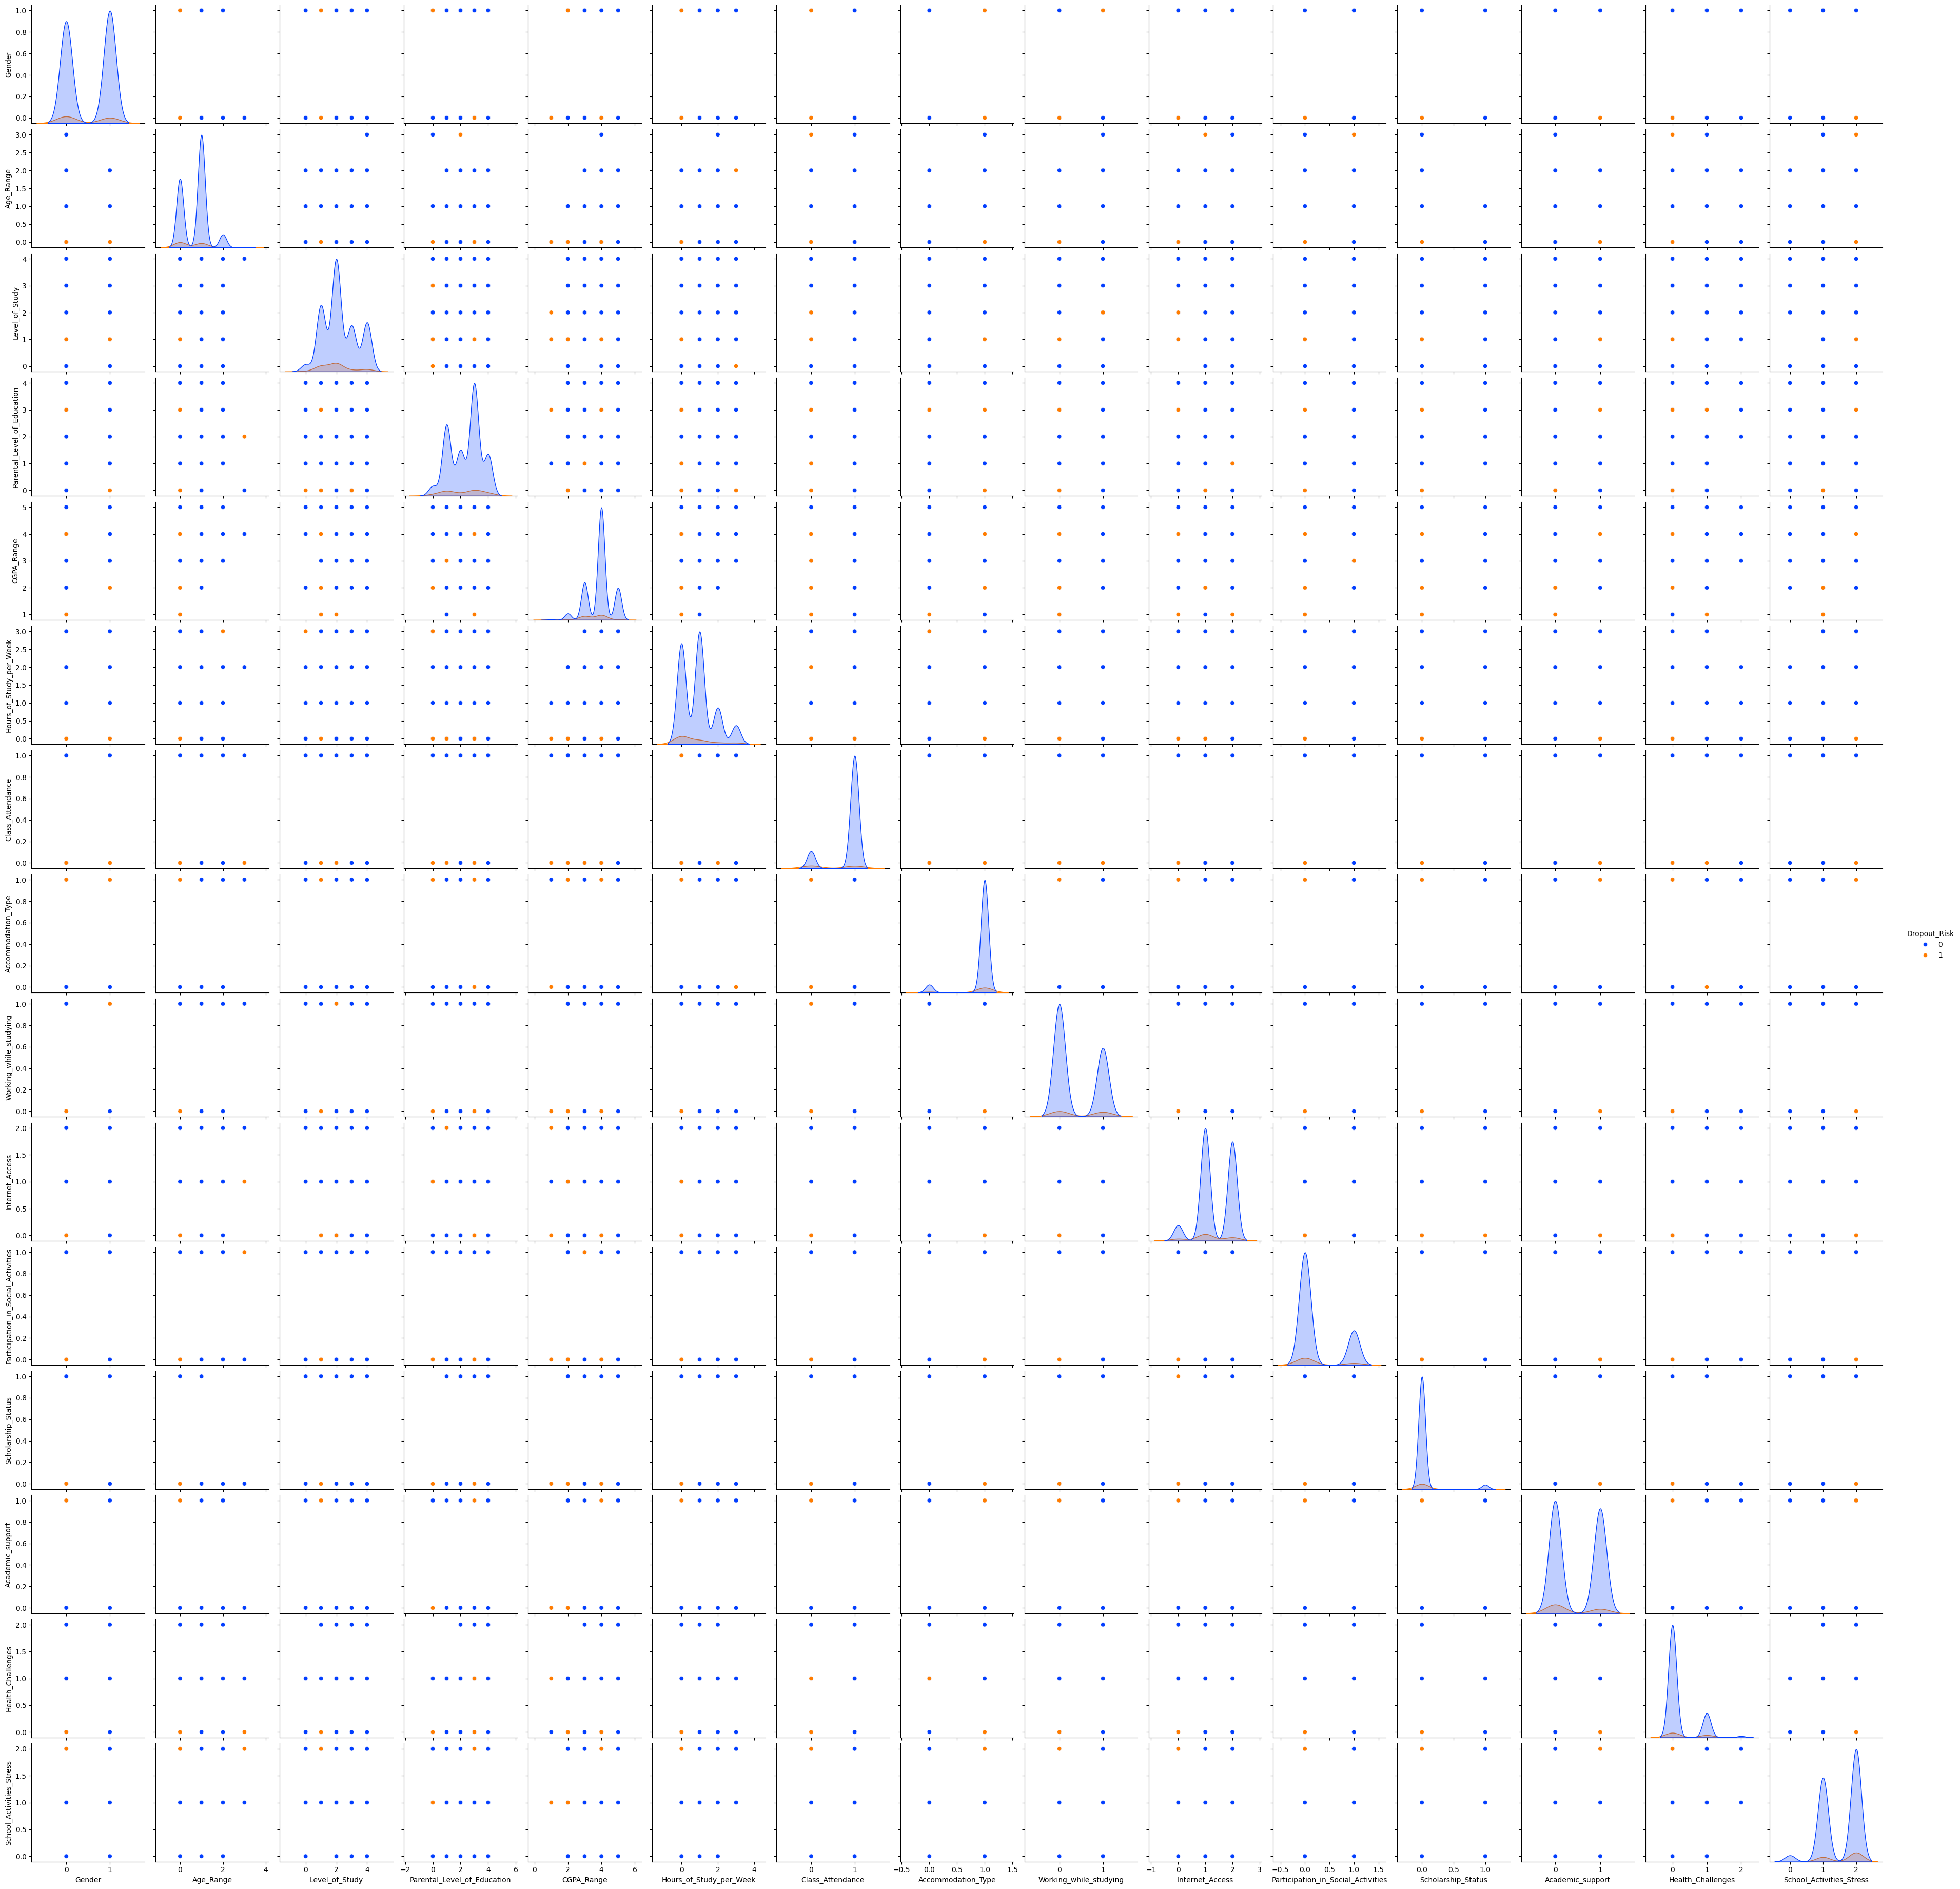

In [51]:
# Pairplot using Dropout risk as hue
sns.pairplot(data[numeric_cols], hue='Dropout_Risk', palette='bright', diag_kind='kde')
plt.show()

### Insight:
From the pairplot, it is clear that students with higher CGPA,level of parent education, more hours of study per week, and better class attendance tend to have lower dropout intention.

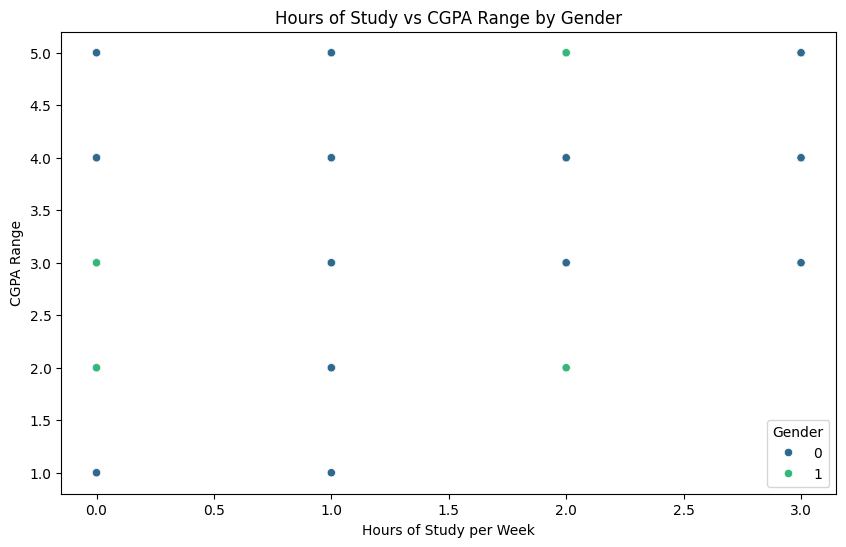

In [52]:
# Scater plot
# Example scatter plot of Hours_of_Study_per_Week vs CGPA_Range, colored by Gender
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=data, 
    x='Hours_of_Study_per_Week', 
    y='CGPA_Range', 
    hue='Gender',     # Change or add more hue variables as needed
    palette='viridis'
)
plt.title('Hours of Study vs CGPA Range by Gender')
plt.xlabel('Hours of Study per Week')
plt.ylabel('CGPA Range')
plt.legend(title='Gender')
plt.show()

In [53]:
data.to_csv('preprocessed_data().csv',index=False)